In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import scienceplots
import corner
import imageio
import io
#plt.style.use(['science', 'notebook', 'grid'])

In [5]:
filename = '/user/animesh.sah/DESI_PECVEL/w_theta_grid_covariance.h5'  
f = h5py.File(filename, 'r')

In [6]:
def print_structure(name, obj):
    """Recursively print HDF5 structure"""
    if isinstance(obj, h5py.Group):
        print(f"\n📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"  📊 Dataset: {name}")
        print(f"      Shape: {obj.shape}")
        print(f"      Dtype: {obj.dtype}")
        print(f"      Size: {obj.size * obj.dtype.itemsize / 1e6:.2f} MB")

f.visititems(print_structure)


📁 Group: grid_data
  📊 Dataset: grid_data/cov
      Shape: (51, 51, 51, 50, 50)
      Dtype: float32
      Size: 1326.51 MB
  📊 Dataset: grid_data/n_bins
      Shape: (51, 51, 51)
      Dtype: int16
      Size: 0.27 MB
  📊 Dataset: grid_data/n_objects
      Shape: (51, 51, 51)
      Dtype: int32
      Size: 0.53 MB
  📊 Dataset: grid_data/theta_bins
      Shape: (51, 51, 51, 50)
      Dtype: float32
      Size: 26.53 MB
  📊 Dataset: grid_data/valid_mask
      Shape: (51, 51, 51)
      Dtype: bool
      Size: 0.13 MB
  📊 Dataset: grid_data/varxi
      Shape: (51, 51, 51, 50)
      Dtype: float32
      Size: 26.53 MB
  📊 Dataset: grid_data/w_theta
      Shape: (51, 51, 51, 50)
      Dtype: float32
      Size: 26.53 MB

📁 Group: metadata
  📊 Dataset: metadata/grid_values
      Shape: (51,)
      Dtype: float64
      Size: 0.00 MB
  📊 Dataset: metadata/reference_theta_bins
      Shape: (50,)
      Dtype: float64
      Size: 0.00 MB
  📊 Dataset: metadata/reference_w_theta
      Shape: (50,)

In [7]:
print('Creation date of the structure: ',f['metadata'].attrs['creation_date']) 


Creation date of the structure:  2026-03-18T05:59:21


In [8]:
grid_values = f['metadata/grid_values'][:]
reference_theta_bins = f['metadata/reference_theta_bins'][:]
reference_w_theta = f['metadata/reference_w_theta'][:]
n_objects = f['grid_data/n_objects'][:]
print(f"Grid values: {len(grid_values)} points")
print(f"Range: [{grid_values.min():.4f}, {grid_values.max():.4f}]")
print(f"Grid values: {grid_values}")
print(f"\nReference theta bins: {len(reference_theta_bins)} bins")
print(f"Theta range: [{reference_theta_bins.min():.4f}, {reference_theta_bins.max():.4f}] degrees")


Grid values: 51 points
Range: [-0.2500, 0.2500]
Grid values: [ 0.25  0.24  0.23  0.22  0.21  0.2   0.19  0.18  0.17  0.16  0.15  0.14
  0.13  0.12  0.11  0.1   0.09  0.08  0.07  0.06  0.05  0.04  0.03  0.02
  0.01  0.   -0.01 -0.02 -0.03 -0.04 -0.05 -0.06 -0.07 -0.08 -0.09 -0.1
 -0.11 -0.12 -0.13 -0.14 -0.15 -0.16 -0.17 -0.18 -0.19 -0.2  -0.21 -0.22
 -0.23 -0.24 -0.25]

Reference theta bins: 50 bins
Theta range: [0.0108, 14.0456] degrees


In [9]:
for key in f['metadata'].attrs.keys():
    print(f"  {key}: {f['metadata'].attrs[key]}")
theta_bins_array = f['grid_data/theta_bins'][:]
w_theta_array = f['grid_data/w_theta'][:]
n_objects_array = f['grid_data/n_objects'][:]
valid_mask = f['grid_data/valid_mask'][:]
n_bins_array = f['grid_data/n_bins'][:]

  creation_date: 2026-03-18T05:59:21
  dimensions: 3
  n_points: 51


In [10]:
i_example, j_example,k_example = len(grid_values) // 4, len(grid_values) // 2 , len(grid_values)//3
#i_example, j_example,k_example = 0,0,0

zp_G_example = grid_values[i_example]
zp_R_example = grid_values[j_example]
zp_Z_example = grid_values[k_example]
print(f"Grid point ({i_example}, {j_example},{k_example})")
print(f"ZP_G = {zp_G_example:.4f}, ZP_R = {zp_R_example:.4f}, zp_Z =  {zp_Z_example:.4f} ")
print(f"N objects: {n_objects_array[i_example, j_example,k_example]}")
print(f"N bins: {n_bins_array[i_example, j_example,k_example]}")
print(f"Valid: {valid_mask[i_example, j_example,k_example]}")

Grid point (12, 25,17)
ZP_G = 0.1300, ZP_R = 0.0000, zp_Z =  0.0800 
N objects: 4909
N bins: 50
Valid: True


In [11]:
#w_ref_backup = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_50_1000_1000_0.01_to_10_w_True_partial_percentile.npy')
w_ref_backup = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_50_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
w_north_backup = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_50_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
cov_south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_50_0.01_to_15_w_True_partial_percentile_covariance.npy')
# plt.errorbar(w_ref_backup[0], w_ref_backup[1], yerr=w_ref_backup[2], fmt='k',ls='None', label='Reference South')
w_ref_backup = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
# plt.errorbar(w_ref_backup[0], w_ref_backup[1], yerr=w_ref_backup[2], fmt='b',ls='None', label='Reference North',alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')

In [12]:
def calculate_chi_square(w_theta_grid, w_theta_ref, theta_bins_grid, theta_bins_ref,cov = 1):
    """
    Calculate chi-square between grid w_theta and reference w_theta
    by interpolating to match theta bins
    """
    # Interpolate grid w_theta to reference theta bins
    w_theta_interp = np.interp(theta_bins_ref, theta_bins_grid, w_theta_grid)
    
    # Calculate chi-square (assuming Poisson errors proportional to w_theta)
    # Using reference w_theta as the uncertainty estimate
    if len(cov.shape) > 1: 
        inv_cov = np.linalg.inv(cov)
        chi_square = (w_theta_interp - w_theta_ref).T @ inv_cov @ (w_theta_interp - w_theta_ref)
    else:   
        chi_square = np.sum((w_theta_grid - w_theta_ref)**2 / (cov**2))
    
    return chi_square

def calculate_chi_square_num_objects(n_objects, n_objects_ref=337336, area_north=5167.3 ,area_south=12213.4,lambda_ =1):
    """
    Calculate chi-square for number of objects based on density difference
    """
    density_model = n_objects / area_north
    density_ref = n_objects_ref / area_south
    sigma_n = np.sqrt(n_objects_ref) / area_south   # treat reference as the noisy data

    chi_density = np.sum((density_model - density_ref)**2 / sigma_n**2)
    
    return lambda_ * chi_density

def calculate_chi_square_area(w_theta_grid, w_theta_ref, theta_bins_grid, theta_bins_ref,n_objects,n_objects_ref=337336,cov= 1,area_north=5167.3 ,area_south=12213.4,lambda_ =0.0,normalize = False):
    """
    Calculate chi-square between grid w_theta and reference w_theta
    by interpolating to match theta bins
    """
    # Interpolate grid w_theta to reference theta bins
    #w_theta_interp = np.interp(theta_bins_ref, theta_bins_grid, w_theta_grid)
    
    # Calculate chi-square (assuming Poisson errors proportional to w_theta)
    # Using reference w_theta as the uncertainty estimate
    if len(cov.shape) > 1: 
        inv_cov = np.linalg.inv(cov)
        chi_square = (w_theta_grid - w_theta_ref).T @ inv_cov @ (w_theta_grid - w_theta_ref)
    else:
        chi_square = np.sum((w_theta_grid - w_theta_ref)**2 / (cov**2))
    density_model = n_objects / area_north
    density_ref = n_objects_ref/ area_south
    sigma_n = np.sqrt(n_objects_ref) / area_south   # treat reference as the noisy data

    chi_density = np.sum((density_model - density_ref)**2 / sigma_n**2)
    if not normalize:
        return chi_square + lambda_ * chi_density
    else: 

        print('CAUTION: Please do not use this option, this is for debugging purposes only')
        alpha = chi_density/chi_square
        return alpha*chi_square + lambda_ * chi_density

# Calculate chi-square for all valid grid points
chi_square_grid = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)

# for i in range(len(grid_values)):
#     for j in range(len(grid_values)):
#         for k in range(len(grid_values)):
#             if valid_mask[i, j, k]:
#                 n_bins = n_bins_array[i, j, k]
#                 theta_bins = theta_bins_array[i, j, k, :n_bins]
#                 w_theta = w_theta_array[i, j, k, :n_bins]
                
#                 chi_square_grid[i, j, k] = calculate_chi_square(
#                     w_theta, w_ref_backup[1], theta_bins, w_ref_backup[0],w_ref_backup[-1]
#                 )

# print(f"Chi-square grid shape: {chi_square_grid.shape}")
# print(f"Min chi-square: {np.min(chi_square_grid[valid_mask]):.2f}")
# print(f"Max chi-square: {np.max(chi_square_grid[valid_mask]):.2f}")

# # Find best-fit grid point
# best_idx = np.unravel_index(np.argmin(chi_square_grid), chi_square_grid.shape)
# print(f"\nBest-fit grid point: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})")
# print(f"ZP_G = {grid_values[best_idx[0]]:.4f}, ZP_R = {grid_values[best_idx[1]]:.4f}, ZP_Z = {grid_values[best_idx[2]]:.4f}")
# print(f"Chi-square = {chi_square_grid[best_idx]:.2f}")
area_north=5167.3 
area_south=12213.4
n_objects_ref=337336

In [13]:
chi_square_grid = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
chi_square_density = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
chi_square_w_theta = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
for i in range(len(grid_values)):
    for j in range(len(grid_values)):
        for k in range(len(grid_values)):
            if valid_mask[i, j, k]:
                n_bins = n_bins_array[i, j, k]
                theta_bins = theta_bins_array[i, j, k, :n_bins]
                w_theta = w_theta_array[i, j, k, :n_bins]
                
                chi_square_grid[i, j, k] = calculate_chi_square(
                    w_theta, w_ref_backup[1], theta_bins, w_ref_backup[0],w_ref_backup[-1]
                )
                chi_square_density[i, j, k] = calculate_chi_square_num_objects(
                    n_objects_array[i, j, k], n_objects_ref, area_north, area_south, lambda_=1
                )
                chi_square_w_theta[i, j, k] = calculate_chi_square(
                    w_theta, w_ref_backup[1], theta_bins, w_ref_backup[0],w_ref_backup[-1]
                )


print(f"Chi-square grid shape: {chi_square_grid.shape}")
print(f"Min chi-square: {np.min(chi_square_grid[valid_mask]):.2f}")
print(f"Max chi-square: {np.max(chi_square_grid[valid_mask]):.2f}")

# Find best-fit grid point
best_idx = np.unravel_index(np.argmin(chi_square_grid), chi_square_grid.shape)
print(f"\nBest-fit grid point: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})")
print(f"ZP_G = {grid_values[best_idx[0]]:.4f}, ZP_R = {grid_values[best_idx[1]]:.4f}, ZP_Z = {grid_values[best_idx[2]]:.4f}")
print(f"Chi-square = {chi_square_grid[best_idx]:.2f}")

Chi-square grid shape: (51, 51, 51)
Min chi-square: 30.76
Max chi-square: 8784147263.52

Best-fit grid point: (27, 35, 46)
ZP_G = -0.0200, ZP_R = -0.1000, ZP_Z = -0.2100
Chi-square = 30.76


Text(0.5, 1.0, 'Distribution of Chi-Square Values')

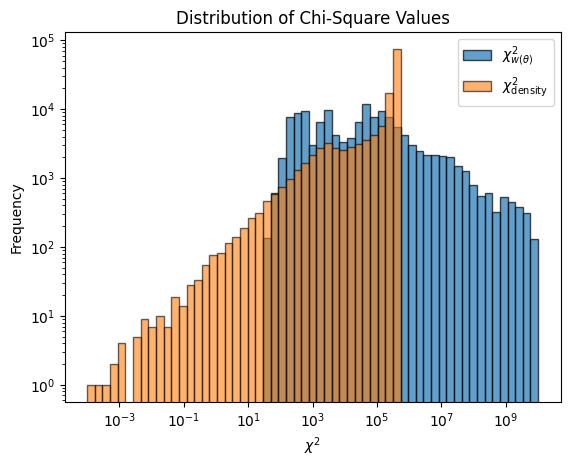

In [14]:
bins = np.logspace(-4,10,60)
plt.hist(chi_square_grid[valid_mask].ravel(), bins=bins, log=True,label = r'$\chi^2_{w(\theta)}$',alpha=0.7,edgecolor='black' )
plt.hist(chi_square_density[valid_mask].ravel(), bins=bins, log=True, alpha=0.6, label = r'$\chi^2_{\mathrm{density}}$',edgecolor='black'   )
plt.xscale('log')
plt.legend()
plt.xlabel(r'$\chi^2$')
plt.ylabel('Frequency')
plt.title('Distribution of Chi-Square Values')

Text(0.5, 1.0, 'Distribution of Chi-Square Values')

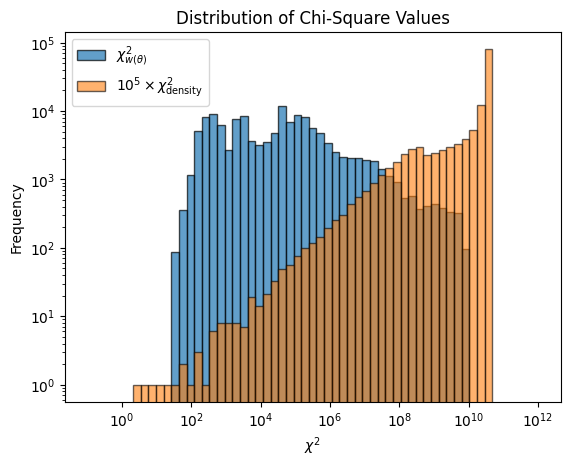

In [15]:
bins = np.logspace(-1,12,60)
plt.hist(chi_square_grid[valid_mask].ravel(), bins=bins, log=True,label = r'$\chi^2_{w(\theta)}$',alpha=0.7,edgecolor='black' )
plt.hist(1e5*chi_square_density[valid_mask].ravel(), bins=bins, log=True, alpha=0.6, label = r'$10^5 \times \chi^2_{\mathrm{density}}$',edgecolor='black'   )
plt.xscale('log')
plt.legend()
plt.xlabel(r'$\chi^2$')
plt.ylabel('Frequency')
plt.title('Distribution of Chi-Square Values')

In [16]:
true_values = [0.0403,0.0206,0.0234]


In [17]:
# Find indices of 5 minimum chi-square values
min_indices = np.argsort(chi_square_grid.ravel())[:100]

# Convert flat indices to 3D indices
min_3d_indices = np.unravel_index(min_indices, chi_square_grid.shape)

# Extract the 5 minimum points
print("Top 5 minimum chi-square points:\n")
print(f"{'Index':<8} {'ZP_G':<12} {'ZP_R':<12} {'ZP_Z':<12} {'χ²':<15}")
print("-" * 60)

for idx_num in range(100):
    i, j, k = min_3d_indices[0][idx_num], min_3d_indices[1][idx_num], min_3d_indices[2][idx_num]
    zp_g = grid_values[i]
    zp_r = grid_values[j]
    zp_z = grid_values[k]
    chi_val = chi_square_grid[i, j, k]
    
    print(f"{idx_num+1:<8} {zp_g:<12.6f} {zp_r:<12.6f} {zp_z:<12.6f} {chi_val:<15.6f}")

Top 5 minimum chi-square points:

Index    ZP_G         ZP_R         ZP_Z         χ²             
------------------------------------------------------------
1        -0.020000    -0.100000    -0.210000    30.762888      
2        -0.050000    -0.130000    -0.240000    30.839119      
3        -0.060000    -0.140000    -0.250000    31.370687      
4        -0.010000    -0.090000    -0.200000    31.443592      
5        -0.040000    -0.120000    -0.230000    32.039942      
6        0.000000     -0.080000    -0.190000    32.309771      
7        0.010000     -0.070000    -0.180000    32.495105      
8        -0.030000    -0.110000    -0.220000    32.570157      
9        0.060000     -0.040000    -0.160000    33.163776      
10       0.000000     -0.100000    -0.220000    33.445790      
11       0.020000     -0.080000    -0.200000    33.505220      
12       0.020000     -0.060000    -0.170000    33.618615      
13       0.040000     -0.060000    -0.180000    33.636301      
14       

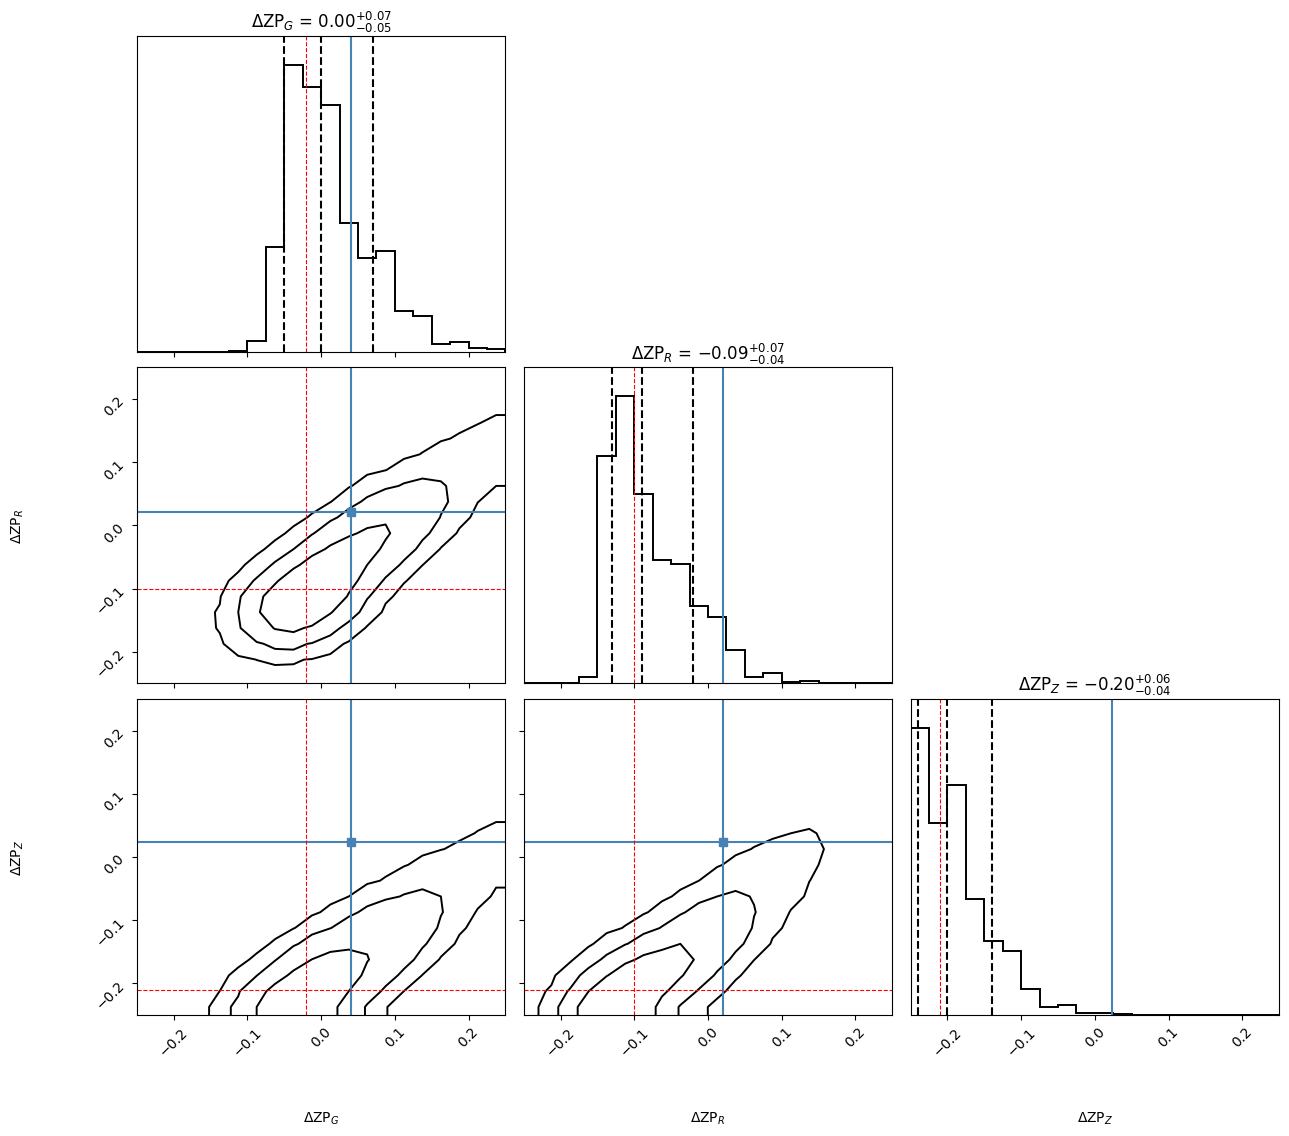

In [18]:



# --- weights: convert Δχ² → likelihood weights ---
delta_chi2 = chi_square_grid - np.nanmin(chi_square_grid)
weights_raw = np.exp(-delta_chi2.ravel() / 2)

# --- filter: only valid, finite points ---
mask = valid_mask.ravel() & np.isfinite(weights_raw) & (weights_raw > 0)

Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])

samples_valid = samples[mask]
weights_valid = weights_raw[mask]

# normalise weights (not required by corner but avoids numerical issues)
weights_valid /= weights_valid.sum()

fig = plt.figure(figsize=(14, 12))
fig = corner.corner(
    samples_valid,
    weights=weights_valid,
    labels=[r"$\Delta\mathrm{ZP}_G$", r"$\Delta\mathrm{ZP}_R$", r"$\Delta\mathrm{ZP}_Z$"],
    levels=[0.68, 0.95, 0.997],          # 1σ, 2σ, 3σ — last value was ~1.0, causes edge artifacts
    fill_contours=False,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    show_titles=True,                    # shows marginalized best-fit ± from the 1D histograms
    quantiles=[0.16, 0.5, 0.84],
    contour_kwargs={"linewidths": 1.4},
    hist_kwargs={"linewidth": 1.4},
    fig=fig,
    truths = true_values    
)



best_idx = np.unravel_index(np.nanargmin(chi_square_grid), chi_square_grid.shape)
best_point = [grid_values[i] for i in best_idx]

# overplot on corner figure
axes = np.array(fig.axes).reshape(3, 3)
for i in range(3):
    for j in range(i):
        axes[i, j].axvline(best_point[j], color='red', lw=0.8, ls='--')
        axes[i, j].axhline(best_point[i], color='red', lw=0.8, ls='--')
for i in range(3):
    axes[i, i].axvline(best_point[i], color='red', lw=0.8, ls='--')

In [50]:

chi = chi_square_grid - np.nanmin(chi_square_grid)
grid = grid_values
frames = []
# Find global 200 minimum chi-square values
min_200_indices = np.argsort(chi.ravel())[:200]
min_200_values = chi.ravel()[min_200_indices]
min_200_threshold = min_200_values[-1]

for k in range(len(grid)):
    slice_2d = chi[:, k, :] 
    slice_2d = np.where(np.isinf(slice_2d), np.nan, slice_2d)
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    
    # Find 5 minimum chi-square values in this slice
    valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
    valid_chi = slice_2d[valid_mask_slice]
    valid_indices = np.where(valid_mask_slice)
    
    if len(valid_chi) > 0:
        n_min = min(10, len(valid_chi))
        min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
        
        min_i = valid_indices[0][min_indices]
        min_j = valid_indices[1][min_indices]
        min_chi_values = valid_chi[min_indices]
        
        # Sort by chi-square value
        sort_order = np.argsort(min_chi_values)
        min_i = min_i[sort_order]
        min_j = min_j[sort_order]
        min_chi_values = min_chi_values[sort_order]
        
        # Check if any of the 5 minima are in top 200 global minima
        if np.any(min_chi_values <= min_200_threshold):

            fig, ax = plt.subplots(figsize=(8, 6))
            cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,150,200], cmap='YlGnBu')
            plt.colorbar(cs, ax=ax, label='Δχ²')
            plt.plot(true_values[0], true_values[2], 'rX', markersize=12, label='True  ZP diff')
            # Plot the 5 minimum points
            for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                if chi_val <= min_200_threshold:
                    ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                            edgecolors='black', linewidths=1.5, zorder=10)
                    ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                        va='center', color='white', fontweight='bold')
            
            ax.set_title(f"Δχ² contour at ZP_R = {grid[k]:.4f}")
            ax.set_xlabel("ZP_G")
            ax.set_ylabel("ZP_Z")

            
            # Print the coordinates of the 5 minima
            print(f"\nFor ZP_R = {grid[k]:.4f}:")
            print(f"{'Rank':<6} {'ZP_G':<12} {'ZP_Z':<12} {'Δχ²':<12}")
            print("-" * 45)
            for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                if chi_val <= min_200_threshold:
                    print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
            
            plt.tight_layout()
            plt.legend()
            buf = io.BytesIO()
            plt.savefig(buf, format='png')
            buf.seek(0)
            frames.append(imageio.v2.imread(buf))
            buf.close()

            plt.close(fig)
            #plt.show()
imageio.mimsave('chi_square_w_theta_animation_R_band.gif', frames, duration=200)



For ZP_R = 0.1800:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.0700       21.2635     

For ZP_R = 0.1700:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.0600       16.6070     
2      0.2400       0.0600       19.1518     

For ZP_R = 0.1600:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2400       0.0500       17.6247     
2      0.2300       0.0500       19.7403     
3      0.2500       0.0400       21.4553     

For ZP_R = 0.1500:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.0300       9.9270      
2      0.2300       0.0400       16.5078     
3      0.2200       0.0400       20.0826     

For ZP_R = 0.1400:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2400       0.0200

In [49]:
frames= []
for k in range(len(grid)):
        slice_2d = chi[k,: , :] 
        slice_2d = np.where(np.isinf(slice_2d),np.nan, slice_2d)
        X, Y = np.meshgrid(grid, grid, indexing='ij')
        
        # Find 5 minimum chi-square values in this slice
        valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
        valid_chi = slice_2d[valid_mask_slice]
        valid_indices = np.where(valid_mask_slice)
        
        if len(valid_chi) > 0:
            n_min = min(10, len(valid_chi))
            min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
            
            min_i = valid_indices[0][min_indices]
            min_j = valid_indices[1][min_indices]
            min_chi_values = valid_chi[min_indices]
            
            # Sort by chi-square value
            sort_order = np.argsort(min_chi_values)
            min_i = min_i[sort_order]
            min_j = min_j[sort_order]
            min_chi_values = min_chi_values[sort_order]
            
            # Check if any of the 5 minima are in top 200 global minima
            if np.any(min_chi_values <= min_200_threshold):

                fig, ax = plt.subplots(figsize=(8, 6))
                cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,150,200], cmap='YlGnBu')
                plt.colorbar(cs, ax=ax, label='Δχ²')
                plt.plot(true_values[1], true_values[2], 'rX', markersize=12, label='True ZP diff')
                # Plot the 5 minimum points
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                                edgecolors='black', linewidths=1.5, zorder=10)
                        ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                            va='center', color='white', fontweight='bold')
                
                ax.set_title(f"Δχ² contour at ZP_G = {grid[k]:.4f}")
                ax.set_xlabel("ZP_R")
                ax.set_ylabel("ZP_Z")
                
                # Print the coordinates of the 5 minima
                print(f"\nFor ZP_G = {grid[k]:.4f}:")
                print(f"{'Rank':<6} {'ZP_R':<12} {'ZP_Z':<12} {'Δχ²':<12}")
                print("-" * 45)
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
                plt.legend()
                plt.tight_layout()
                buf = io.BytesIO()
                plt.savefig(buf, format='png')
                buf.seek(0)
                frames.append(imageio.v2.imread(buf))
                buf.close()

                plt.close(fig)
            #plt.show()
imageio.mimsave('chi_square_w_theta_animation_G_band.gif', frames, duration=200)



For ZP_G = 0.2500:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1500       0.0300       9.9270      
2      0.1700       0.0600       16.6070     
3      0.1800       0.0700       21.2635     
4      0.1600       0.0400       21.4553     

For ZP_G = 0.2400:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1400       0.0200       10.1724     
2      0.1600       0.0500       17.6247     
3      0.1700       0.0600       19.1518     

For ZP_G = 0.2300:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1300       0.0100       9.7320      
2      0.1500       0.0400       16.5078     
3      0.1600       0.0500       19.7403     

For ZP_G = 0.2200:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1200       0.0000       10.6680     
2      0.1400       0.0300       16.5710     


In [48]:
frames=[]
for k in range(len(grid)):
        slice_2d = chi[:,: , k] 
        slice_2d = np.where(np.isinf(slice_2d),np.nan, slice_2d)
        X, Y = np.meshgrid(grid, grid, indexing='ij')
        
        # Find 5 minimum chi-square values in this slice
        valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
        valid_chi = slice_2d[valid_mask_slice]
        valid_indices = np.where(valid_mask_slice)
        
        if len(valid_chi) > 0:
            n_min = min(10, len(valid_chi))
            min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
            
            min_i = valid_indices[0][min_indices]
            min_j = valid_indices[1][min_indices]
            min_chi_values = valid_chi[min_indices]
            
            # Sort by chi-square value
            sort_order = np.argsort(min_chi_values)
            min_i = min_i[sort_order]
            min_j = min_j[sort_order]
            min_chi_values = min_chi_values[sort_order]
            
            # Check if any of the 5 minima are in top 200 global minima
            if np.any(min_chi_values <= min_200_threshold):

                fig, ax = plt.subplots(figsize=(8, 6))
                cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,150,200], cmap='YlGnBu')
                plt.colorbar(cs, ax=ax, label='Δχ²')
                plt.plot(true_values[0], true_values[1], 'rX', markersize=12, label='True ZP diff')
                # Plot the 5 minimum points
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                                edgecolors='black', linewidths=1.5, zorder=10)
                        ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                            va='center', color='white', fontweight='bold')
                
                ax.set_title(f"Δχ² contour at ZP_Z = {grid[k]:.4f}")
                ax.set_xlabel("ZP_G")
                ax.set_ylabel("ZP_R")
                plt.legend()
                # Print the coordinates of the 5 minima
                print(f"\nFor ZP_Z = {grid[k]:.4f}:")
                print(f"{'Rank':<6} {'ZP_G':<12} {'ZP_R':<12} {'Δχ²':<12}")
                print("-" * 45)
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
                
                plt.tight_layout()
                buf = io.BytesIO()
                plt.savefig(buf, format='png')
                buf.seek(0)
                frames.append(imageio.v2.imread(buf))
                buf.close()

                plt.close(fig)
            #plt.show()
imageio.mimsave('chi_square_w_theta_animation_Z_band.gif', frames, duration=200)


For ZP_Z = 0.0700:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1800       21.2635     

For ZP_Z = 0.0600:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1700       16.6070     
2      0.2400       0.1700       19.1518     

For ZP_Z = 0.0500:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2400       0.1600       17.6247     
2      0.2300       0.1600       19.7403     

For ZP_Z = 0.0400:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2300       0.1500       16.5078     
2      0.2200       0.1500       20.0826     
3      0.2500       0.1600       21.4553     

For ZP_Z = 0.0300:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1500       9.9270      
2      0.2200       0.1400

In [ ]:
condition = np.where(chi < 20)
selected_zp_G = grid_values[condition[0]]
selected_zp_R = grid_values[condition[1]]
selected_zp_Z = grid_values[condition[2]]
selected_chi = chi[condition]

# Sort by chi-square values
sort_indices = np.argsort(selected_chi)
selected_zp_G = selected_zp_G[sort_indices]
selected_zp_R = selected_zp_R[sort_indices]
selected_zp_Z = selected_zp_Z[sort_indices]
selected_chi = selected_chi[sort_indices]

print(f"Number of grid points with Δχ² < 20: {len(selected_chi)}\n")
print("ZP_G\t\tZP_R\t\tZP_Z\t\tΔχ²")
print("-" * 60)
for i in range(len(selected_chi)):
    print(f"{selected_zp_G[i]:.6f}\t{selected_zp_R[i]:.6f}\t{selected_zp_Z[i]:.6f}\t{selected_chi[i]:.6f}")

Number of grid points with Δχ² < 20: 160

ZP_G		ZP_R		ZP_Z		Δχ²
------------------------------------------------------------
-0.020000	-0.100000	-0.210000	0.000000
-0.050000	-0.130000	-0.240000	0.076231
-0.060000	-0.140000	-0.250000	0.607799
-0.010000	-0.090000	-0.200000	0.680704
-0.040000	-0.120000	-0.230000	1.277055
0.000000	-0.080000	-0.190000	1.546884
0.010000	-0.070000	-0.180000	1.732218
-0.030000	-0.110000	-0.220000	1.807270
0.060000	-0.040000	-0.160000	2.400888
0.000000	-0.100000	-0.220000	2.682902
0.020000	-0.080000	-0.200000	2.742333
0.020000	-0.060000	-0.170000	2.855728
0.040000	-0.060000	-0.180000	2.873413
0.100000	0.000000	-0.120000	2.900237
0.080000	-0.020000	-0.140000	2.913192
0.090000	-0.010000	-0.130000	2.942963
-0.030000	-0.130000	-0.250000	2.990555
0.120000	0.020000	-0.100000	3.023258
0.010000	-0.090000	-0.210000	3.026727
0.070000	-0.030000	-0.150000	3.252007
0.030000	-0.070000	-0.190000	3.412299
0.050000	-0.050000	-0.170000	3.485825
-0.010000	-0.110000	-0.230000	3.77

In [ ]:
lambda_array = [0, 0.001,0.005, 0.01, 0.05, 0.1, 1,10,1e5]
def calculate_chi_square_area_wrapper(lambda_):
    for i in range(len(grid_values)):
        for j in range(len(grid_values)):
            for k in range(len(grid_values)):
                if valid_mask[i, j, k]:
                    n_bins = n_bins_array[i, j, k]
                    theta_bins = theta_bins_array[i, j, k, :n_bins]
                    w_theta = w_theta_array[i, j, k, :n_bins]
                    
                    chi_square_grid_area[i, j, k] = calculate_chi_square_area(
                        w_theta, w_ref_backup[1], theta_bins, w_ref_backup[0], cov=w_ref_backup[-1],n_objects=n_objects_array[i, j, k], lambda_=lambda_
                    )
    return chi_square_grid_area
chi_square_grid_lambda = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
#chi_square_grid_lambda = calculate_chi_square_area_wrapper(0.005)

chi_square_lambda={}

for lambda_ in lambda_array:
    chi_square_grid_area = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)

    print(f"\nCalculating chi-square grid with lambda = {lambda_}")
    chi_square_grid_area = calculate_chi_square_area_wrapper(lambda_)

    # Find best-fit grid point
    best_idx = np.unravel_index(np.argmin(chi_square_grid_area), chi_square_grid_area.shape)
    chi_square_lambda[lambda_] = {
        'chi_square_grid': chi_square_grid_area,
        'best_idx': best_idx,
        'ZP_G': grid_values[best_idx[0]],
        'ZP_R': grid_values[best_idx[1]],
        'ZP_Z': grid_values[best_idx[2]],
        'Chi-square': chi_square_grid_area[best_idx],
        'N_objects': n_objects_array[best_idx]
    }


Calculating chi-square grid with lambda = 0

Calculating chi-square grid with lambda = 0.001

Calculating chi-square grid with lambda = 0.005

Calculating chi-square grid with lambda = 0.01

Calculating chi-square grid with lambda = 0.05

Calculating chi-square grid with lambda = 0.1

Calculating chi-square grid with lambda = 1

Calculating chi-square grid with lambda = 10

Calculating chi-square grid with lambda = 100000.0



Calculating chi-square grid with lambda = 0


Min chi-square: 30.76, Max chi-square: 8784147263.52


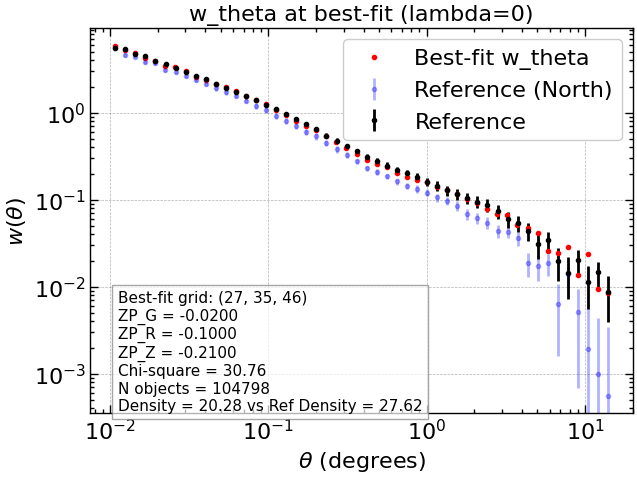


Calculating chi-square grid with lambda = 0.001
Min chi-square: 54.14, Max chi-square: 8784147600.77


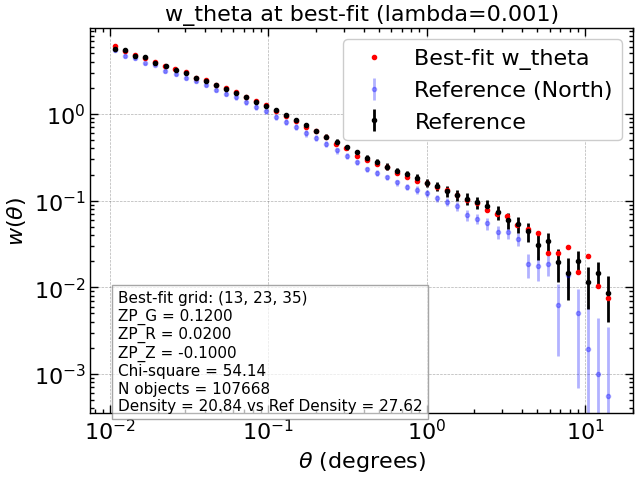


Calculating chi-square grid with lambda = 0.005
Min chi-square: 104.28, Max chi-square: 8784148949.75


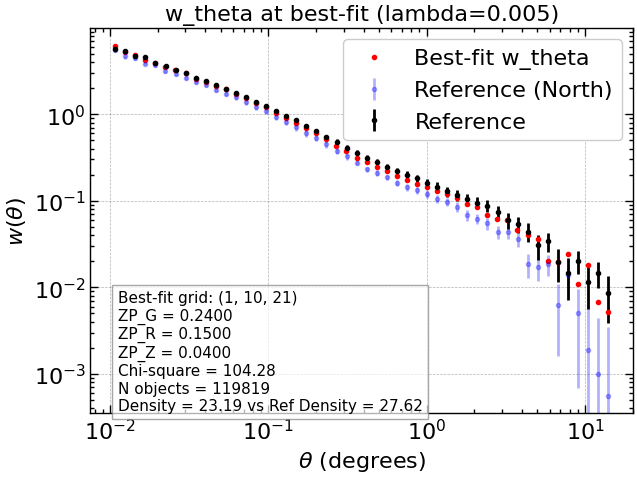


Calculating chi-square grid with lambda = 0.01
Min chi-square: 139.57, Max chi-square: 8784150635.98


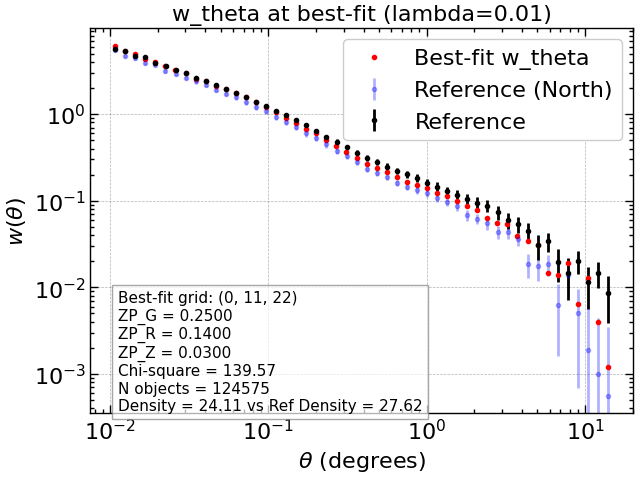


Calculating chi-square grid with lambda = 0.05
Min chi-square: 193.80, Max chi-square: 8784164125.83


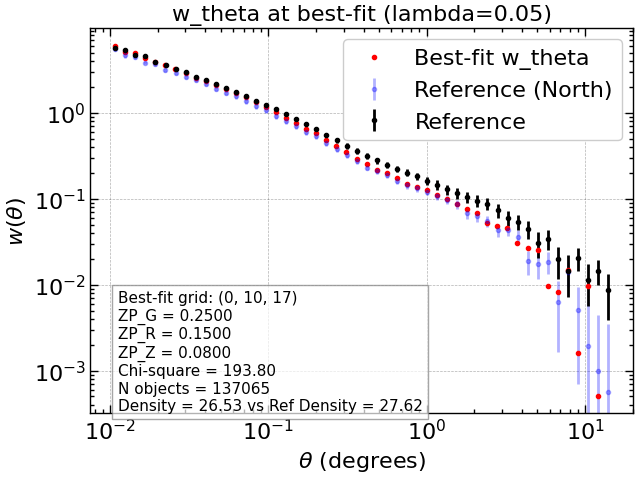


Calculating chi-square grid with lambda = 0.1
Min chi-square: 209.05, Max chi-square: 8784180988.14


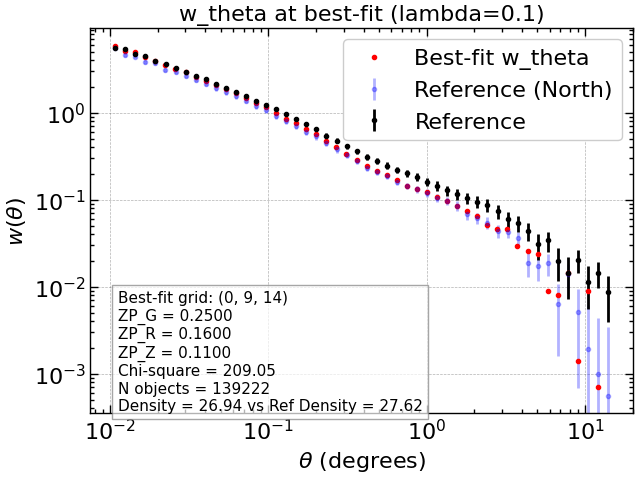


Calculating chi-square grid with lambda = 1
Min chi-square: 227.52, Max chi-square: 8784484509.71


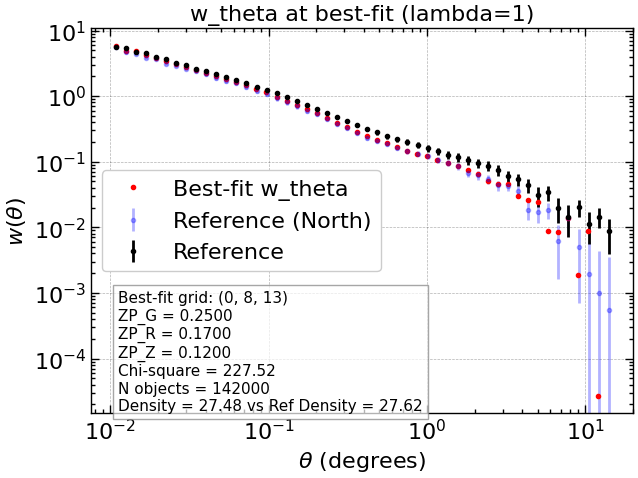


Calculating chi-square grid with lambda = 10
Min chi-square: 228.47, Max chi-square: 8787519725.42


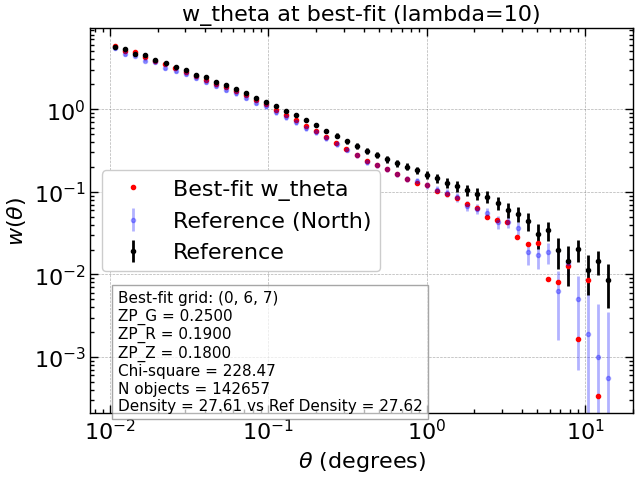


Calculating chi-square grid with lambda = 100000.0
Min chi-square: 351.64, Max chi-square: 42508766203.64


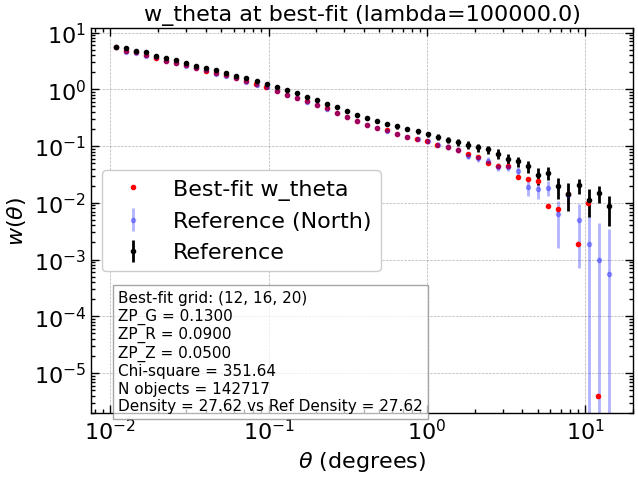

In [ ]:
for lambda_ in lambda_array:
    print('=' * 50)
    chi_square_grid_area = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)

    print(f"\nCalculating chi-square grid with lambda = {lambda_}")
    chi_square_grid_area = calculate_chi_square_area_wrapper(lambda_)

    print(f"Min chi-square: {np.min(chi_square_grid_area[valid_mask]):.2f}, Max chi-square: {np.max(chi_square_grid_area[valid_mask]):.2f}")

    # Find best-fit grid point
    best_idx = np.unravel_index(np.argmin(chi_square_grid_area), chi_square_grid_area.shape)
    # print(f"\nBest-fit grid point: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})")
    # print(f"ZP_G = {grid_values[best_idx[0]]:.4f}, ZP_R = {grid_values[best_idx[1]]:.4f}, ZP_Z = {grid_values[best_idx[2]]:.4f}")
    # print(f"Chi-square = {chi_square_grid_area[best_idx]:.2f}")
    # print(f'Number of objects at best fit: {n_objects_array[best_idx]}')

    # Prepare statistics text
    stats_text = (
        f"Best-fit grid: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})\n"
        f"ZP_G = {grid_values[best_idx[0]]:.4f}\n"
        f"ZP_R = {grid_values[best_idx[1]]:.4f}\n"
        f"ZP_Z = {grid_values[best_idx[2]]:.4f}\n"
        f"Chi-square = {chi_square_grid_area[best_idx]:.2f}\n"
        f"N objects = {n_objects_array[best_idx]}\n"
        f"Density = {n_objects_array[best_idx]/area_north:.2f} vs Ref Density = {n_objects_ref/area_south:.2f}"
    )

    # Plot w_theta at best-fit
    n_bins = n_bins_array[best_idx]
    theta_bins = theta_bins_array[best_idx[0], best_idx[1], best_idx[2], :n_bins]
    w_theta = w_theta_array[best_idx[0], best_idx[1], best_idx[2], :n_bins]

    plt.figure(figsize=(7, 5))
    plt.errorbar(w_north_backup[0], w_north_backup[1], yerr=w_north_backup[-1], fmt= 'b.',alpha=0.3,ls='None', label='Reference (North)')
    plt.errorbar(w_ref_backup[0], w_ref_backup[1], yerr=w_ref_backup[-1], fmt= 'k.',ls='None', label='Reference')
    plt.loglog(theta_bins, w_theta, 'r.', label='Best-fit w_theta')
    plt.xlabel(r'$\theta$ (degrees)')
    plt.ylabel(r'$w(\theta)$')
    plt.title(f'w_theta at best-fit (lambda={lambda_})')
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.gca().text(
        0.05, 0.32, stats_text, transform=plt.gca().transAxes,
        fontsize=11, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    )
    plt.show()


## For normalized $\chi^2$

In [ ]:
chi_square_normalized = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)

for i in range(len(grid_values)):
    for j in range(len(grid_values)):
        for k in range(len(grid_values)):
            if valid_mask[i, j, k]:
                n_bins = n_bins_array[i, j, k]
                theta_bins = theta_bins_array[i, j, k, :n_bins]
                w_theta = w_theta_array[i, j, k, :n_bins]
                chi_square_normalized[i, j, k] = calculate_chi_square_area(
                        w_theta, w_ref_backup[1], theta_bins, w_ref_backup[0], cov=w_ref_backup[-1],n_objects=n_objects_array[i, j, k], lambda_=lambda_,normalize=True
                    )
                


print(f"Chi-square grid shape: {chi_square_normalized.shape}")
print(f"Min chi-square: {np.min(chi_square_normalized[valid_mask]):.2f}")
print(f"Max chi-square: {np.max(chi_square_normalized[valid_mask]):.2f}")

# Find best-fit grid point
best_idx = np.unravel_index(np.argmin(chi_square_normalized), chi_square_normalized.shape)
print(f"\nBest-fit grid point: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})")
print(f"ZP_G = {grid_values[best_idx[0]]:.4f}, ZP_R = {grid_values[best_idx[1]]:.4f}, ZP_Z = {grid_values[best_idx[2]]:.4f}")
print(f"Chi-square = {chi_square_normalized[best_idx]:.2f}")

Chi-square grid shape: (51, 51, 51)
Min chi-square: 3076319.52
Max chi-square: 878423510499488.25

Best-fit grid point: (27, 35, 46)
ZP_G = -0.0200, ZP_R = -0.1000, ZP_Z = -0.2100
Chi-square = 3076319.52


In [ ]:
delta_chi2

array([[[4.23401942e+07, 4.39610193e+07, 4.32786002e+07, ...,
         6.19127580e+09, 6.69952183e+09, 7.38998769e+09],
        [3.62078304e+07, 3.89656189e+07, 4.04326392e+07, ...,
         5.89925502e+09, 6.12602252e+09, 6.28883474e+09],
        [2.76881182e+07, 3.14981369e+07, 3.46841975e+07, ...,
         5.33703921e+09, 5.53922083e+09, 6.01699022e+09],
        ...,
        [8.93104195e+10, 1.60930250e+11, 2.56052271e+11, ...,
         2.40528153e+11, 2.40528153e+11, 2.40528153e+11],
        [9.40673411e+11, 9.40673411e+11, 1.17581192e+11, ...,
         2.75482401e+11, 4.82181268e+11, 4.82181268e+11],
        [9.81912992e+11, 1.30851239e+12, 1.32213284e+12, ...,
         5.67079066e+11, 5.67079066e+11, 5.67079066e+11]],

       [[4.61775097e+07, 4.68389605e+07, 4.50191944e+07, ...,
         6.10480085e+09, 6.54551072e+09, 7.04691470e+09],
        [4.06538834e+07, 4.20885033e+07, 4.36186976e+07, ...,
         6.14631760e+09, 6.34276395e+09, 6.94337070e+09],
        [3.27454794e+07, 

In [ ]:

delta_chi2 = chi_square_normalized - np.nanmin(chi_square_normalized)
weights_raw = np.exp(-delta_chi2.ravel() / 2)

# --- filter: only valid, finite points ---
mask = valid_mask.ravel() & np.isfinite(weights_raw) & (weights_raw > 0)

Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])

samples_valid = samples[mask]
weights_valid = weights_raw[mask]

# normalise weights (not required by corner but avoids numerical issues)
weights_valid /= weights_valid.sum()

fig = plt.figure(figsize=(14, 12))
fig = corner.corner(
    samples_valid,
    weights=weights_valid,
    labels=[r"$\Delta\mathrm{ZP}_G$", r"$\Delta\mathrm{ZP}_R$", r"$\Delta\mathrm{ZP}_Z$"],
    levels=[0.68, 0.95, 0.997],          # 1σ, 2σ, 3σ — last value was ~1.0, causes edge artifacts
    fill_contours=False,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    show_titles=True,                    # shows marginalized best-fit ± from the 1D histograms
    quantiles=[0.16, 0.5, 0.84],
    contour_kwargs={"linewidths": 1.4},
    hist_kwargs={"linewidth": 1.4},
    fig=fig,
    truths = true_values    
)



best_idx = np.unravel_index(np.nanargmin(chi_square_normalized), chi_square_normalized.shape)
best_point = [grid_values[i] for i in best_idx]

# overplot on corner figure
axes = np.array(fig.axes).reshape(3, 3)
for i in range(3):
    for j in range(i):
        axes[i, j].axvline(best_point[j], color='red', lw=0.8, ls='--')
        axes[i, j].axhline(best_point[i], color='red', lw=0.8, ls='--')
for i in range(3):
    axes[i, i].axvline(best_point[i], color='red', lw=0.8, ls='--')

AssertionError: I don't believe that you want more dimensions than samples!

<Figure size 1400x1200 with 0 Axes>

In [ ]:
delta_chi2 = chi_square_grid - np.nanmin(chi_square_grid)
weights_raw = np.exp(-delta_chi2.ravel() / 2)

# --- filter: only valid, finite points ---
mask = valid_mask.ravel() & np.isfinite(weights_raw) & (weights_raw > 0)

Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])

samples_valid = samples[mask]
weights_valid = weights_raw[mask]

# normalise weights (not required by corner but avoids numerical issues)
weights_valid /= weights_valid.sum()

In [ ]:
lambda_array_subset = [0,1]
condition = np.where(valid_mask)


def extract_samples_weights(chi_grid):

    selected_chi = chi_grid - np.nanmin(chi_grid)
    weights_raw = np.exp(-selected_chi.ravel() / 2)
    mask = valid_mask.ravel() & np.isfinite(weights_raw) & (weights_raw > 0)

    Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
    samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])
    samples_valid = samples[mask]
    weights_valid = weights_raw[mask]
    weights_valid /= weights_valid.sum()
    
    return samples_valid, weights_valid



In [ ]:
#calculate_chi_square()

In [ ]:
chi_square_num_objects= np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
chi_square = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)
for i in range(len(grid_values)):
    for j in range(len(grid_values)):
        for k in range(len(grid_values)):
            if valid_mask[i, j, k]:
                n_bins = n_bins_array[i, j, k]
                theta_bins = theta_bins_array[i, j, k, :n_bins]
                num_objects = n_objects_array[i, j, k]
                
                chi_square_num_objects[i, j, k] = calculate_chi_square_num_objects(
                    num_objects,lambda_=1)
                chi_square[i, j, k] = calculate_chi_square(
                    w_theta_array[i, j, k], w_ref_backup[1], theta_bins, w_ref_backup[0], w_ref_backup[-1]
                )

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packa

NameError: name 'legend_lines' is not defined

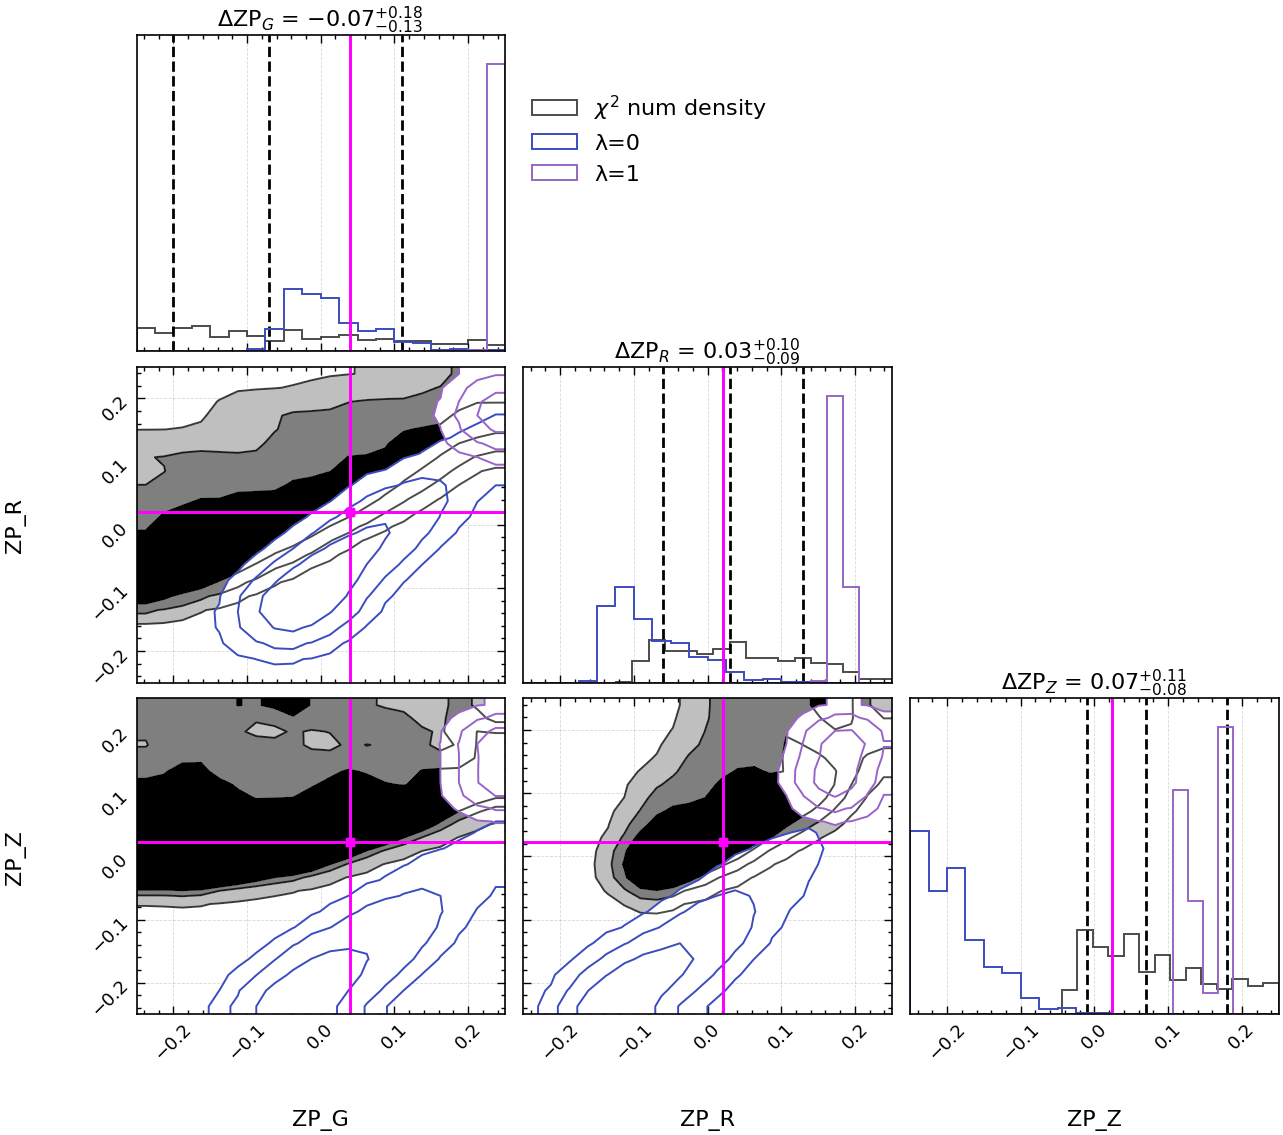

In [ ]:


plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "font.size": 15,
    "axes.linewidth": 1.2,
})
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.15
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.linewidth"] = 0.6
fig = plt.figure(figsize=(14, 12))  
colors = [
    "#3b4cc0", "#9864c8", "#c14a5d", "#e17c2a", "#2aa17b",
     "#d35fb7", "#ef6c4e", "#f4a462",
    "#6bbf5e", "#4c9a91", "#bfa641", "#7e4f9e", "#b85c4f",
    "#5aa3d8", "#32936f"
]


####################################################################
####################################################################
delta_chi2 = chi_square_num_objects - np.nanmin(chi_square_num_objects)
weights_raw = np.exp(-delta_chi2.ravel() / 2)

# --- filter: only valid, finite points ---
mask = valid_mask.ravel() & np.isfinite(weights_raw) & (weights_raw > 0)

Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])

samples_valid = samples[mask]
weights_valid = weights_raw[mask]

# normalise weights (not required by corner but avoids numerical issues)
weights_valid /= weights_valid.sum()

fig = corner.corner(
    samples_valid,
    weights=weights_valid,
    labels=[r"$\Delta\mathrm{ZP}_G$", r"$\Delta\mathrm{ZP}_R$", r"$\Delta\mathrm{ZP}_Z$"],
    levels=[0.68, 0.95, 0.997],          # 1σ, 2σ, 3σ — last value was ~1.0, causes edge artifacts
    fill_contours=True,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    show_titles=True,   
                                     # shows marginalized best-fit ± from the 1D histograms
    quantiles=[0.16, 0.5, 0.84],
    contour_kwargs={"linewidths": 1.4,"alpha": 0.7,"label":r"$\chi^2$ num density"},
    hist_kwargs={"linewidth": 1.4, "alpha": 0.7,"label":r"$\chi^2$ num density"},
    fig=fig,
)
axes = fig.get_axes()
ndim = 3
####################################################################
####################################################################
for idx, lambda_val in enumerate(lambda_array_subset):
    values = chi_square_lambda[lambda_val]
    chi_grid = values['chi_square_grid']
    samples, weights = extract_samples_weights(chi_grid)
    mean_zp = np.average(samples, axis=0, weights=weights)
    cov_zp = np.cov(samples.T, aweights=weights)
    std_zp = np.sqrt(np.diag(cov_zp))
    fig = corner.corner(
        samples,
        weights=weights,
        labels=[r"ZP_G", r"ZP_R", r"ZP_Z"],
        color=colors[idx],
        levels=[0.68, 0.95, 0.997],
        fill_contours=False,
        smooth=1.0,     
        truths=[0.0403, 0.0206, 0.0234],
        truth_color="magenta",
        plot_density=False,
        truth_linestyle=":",
        kde=True,
        plot_datapoints=False,
        show_titles=False,
        contour_kwargs={"linewidths": 1.4, "colors": colors[idx],  "label": f"λ={lambda_val}"},
        hist_kwargs={"linewidth": 1.4, "color": colors[idx], "label": f"λ={lambda_val}"},
        fig=fig
    )



from matplotlib.lines import Line2D
#true2 = [0.086999999999, 0.10200000000000031,0.0470000000000006 ]

for i in range(ndim):
    ax = axes[i*ndim + i]      # diagonal histogram
    #ax.axvline(true2[i], color="black", linestyle="--", linewidth=1.5)

for yi in range(ndim):
    for xi in range(yi):
        ax = axes[yi*ndim + xi]
        #ax.axvline(true2[xi], color="black", linestyle="--", linewidth=1)
       #ax.axhline(true2[yi], color="black", linestyle="--", linewidth=1)





axes[0].legend(
    loc=(10,0.9),
    bbox_to_anchor=(1.05, 0.5),
    fontsize=16,
    frameon=False
)
axes[1].legend(handles = legend_lines,
    loc=(10,0.9),
    bbox_to_anchor=(1.05, 0.5),
    fontsize=16,
    frameon=False
)


axes[0].set_title(r"$e^{-\frac{1}{2}(\chi^2 - \chi^2_{\min})}$"+ "\n  Contours correspond to 1, 3 and 3$\sigma$ contours", fontsize=20, pad=20)
plt.show()


# For $\lambda  =1 $

In [ ]:
chi_square_lambda[0].keys()

dict_keys(['chi_square_grid', 'best_idx', 'ZP_G', 'ZP_R', 'ZP_Z', 'Chi-square', 'N_objects'])

##  GZ plot


For ZP_R = 0.2200:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.2500       24.5715     


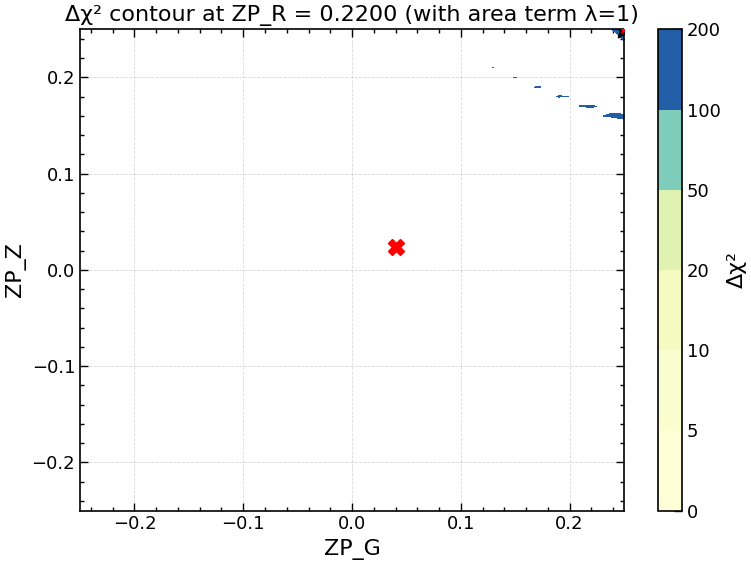


For ZP_R = 0.2100:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.2300       37.7544     
2      0.2400       0.2400       48.6676     


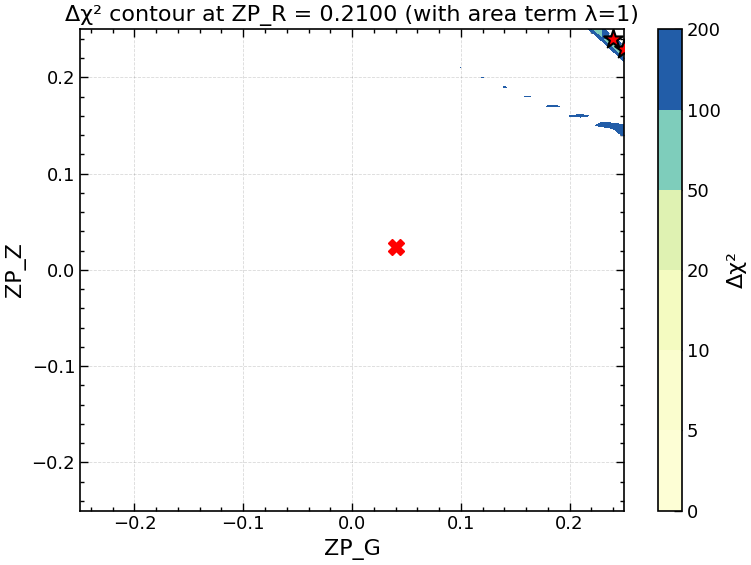


For ZP_R = 0.2000:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.2000       32.4536     


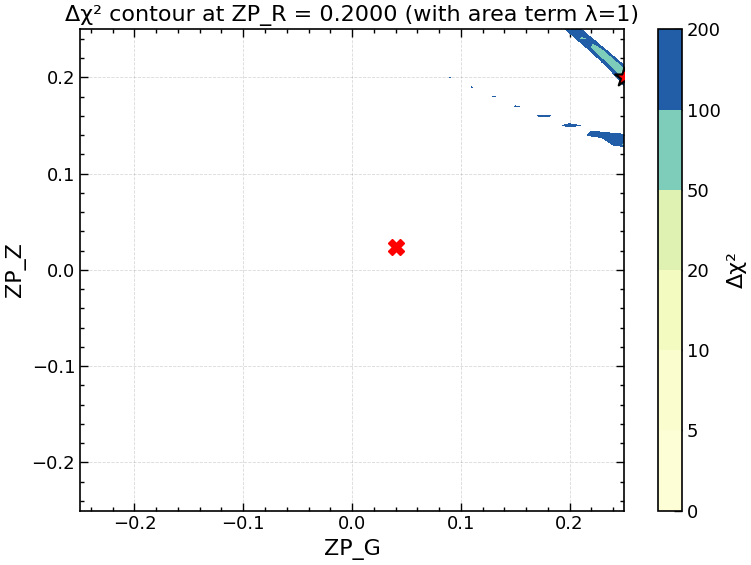


For ZP_R = 0.1900:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.1800       0.3197      
2      0.2400       0.1900       14.2635     
3      0.2500       0.1200       31.0922     
4      0.2300       0.2000       31.4501     
5      0.2200       0.2100       39.3506     
6      0.1800       0.2500       39.9085     
7      0.1900       0.2400       39.9867     
8      0.2000       0.2300       43.2391     
9      0.2100       0.2200       45.3101     


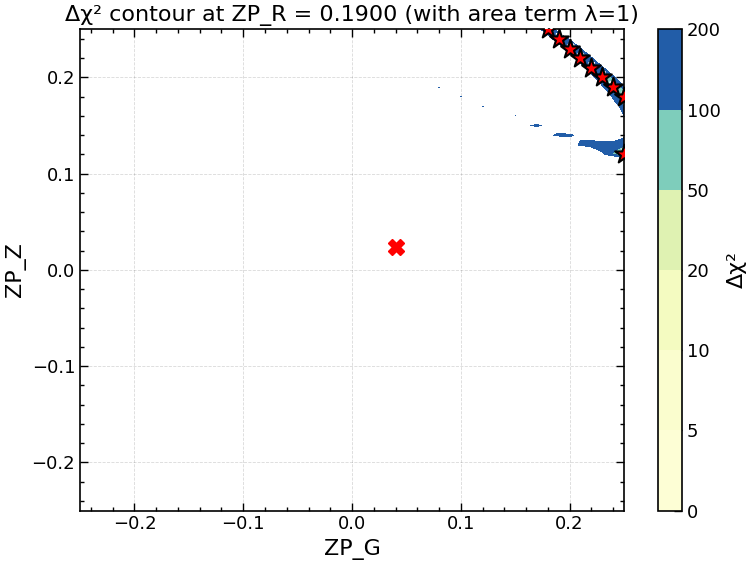


For ZP_R = 0.1800:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2400       0.1700       0.9940      
2      0.2500       0.1500       4.3708      
3      0.2300       0.1800       5.7852      
4      0.2500       0.1600       13.2424     
5      0.2200       0.1900       17.5823     
6      0.2100       0.2000       22.0754     
7      0.2500       0.1100       26.7103     
8      0.2000       0.2100       28.4495     
9      0.1900       0.2200       29.9594     
10     0.1800       0.2300       34.7192     


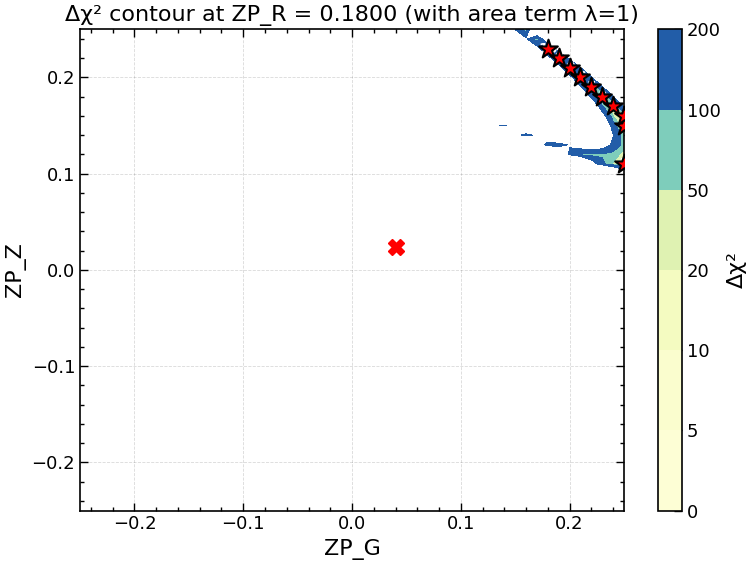


For ZP_R = 0.1700:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2500       0.1200       0.0000      
2      0.2400       0.1400       1.0624      
3      0.2500       0.1100       3.4052      
4      0.2200       0.1700       10.4840     
5      0.2500       0.1300       13.0266     
6      0.2100       0.1800       15.8989     
7      0.2300       0.1600       16.8727     
8      0.2000       0.1900       18.7254     
9      0.2400       0.1100       22.7071     
10     0.2400       0.1300       23.9252     


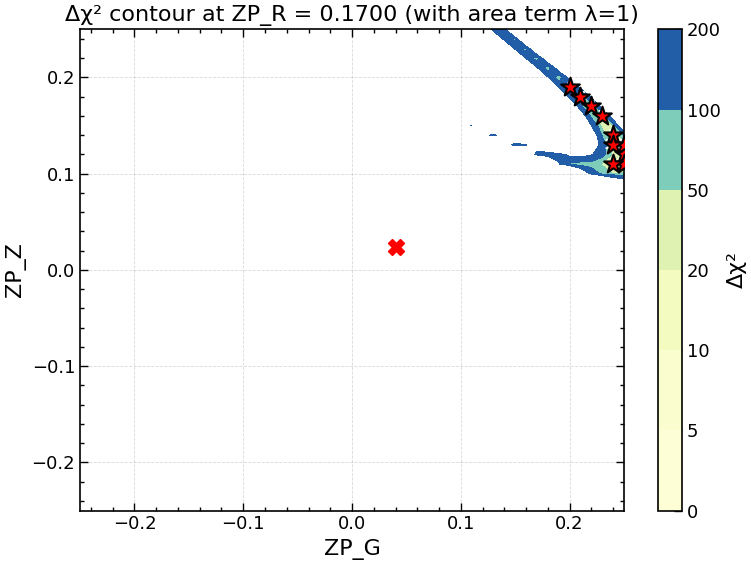


For ZP_R = 0.1600:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2300       0.1300       9.4690      
2      0.2300       0.1200       13.5655     
3      0.2200       0.1400       13.7453     
4      0.2400       0.1100       16.8779     
5      0.2300       0.1000       22.8487     
6      0.2400       0.1000       23.9532     
7      0.2300       0.1100       24.5289     
8      0.2000       0.1700       24.9425     
9      0.2100       0.1600       25.4426     
10     0.1900       0.1800       27.0318     


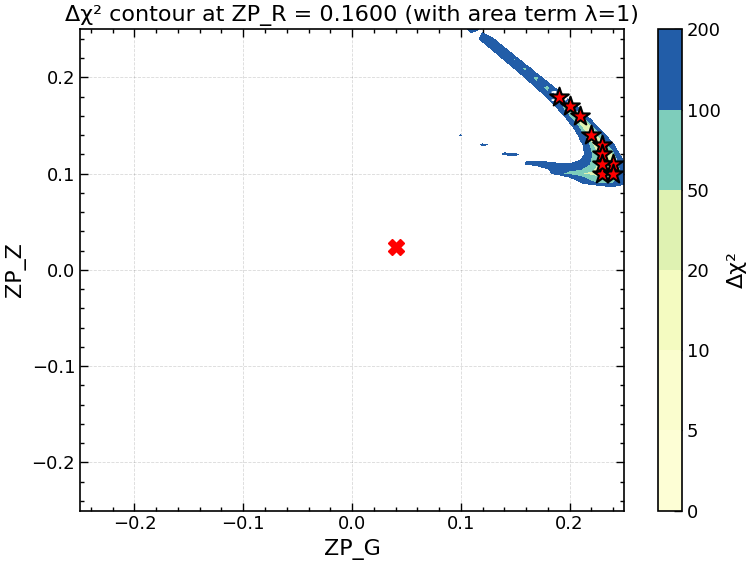


For ZP_R = 0.1500:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.2200       0.1100       10.6375     
2      0.2100       0.1300       12.0396     
3      0.2200       0.1000       17.6064     
4      0.2000       0.1400       23.6134     
5      0.2200       0.1200       27.0228     
6      0.2100       0.1200       29.7975     
7      0.2200       0.0900       30.1188     
8      0.2100       0.0900       31.7284     
9      0.1800       0.1700       42.0687     
10     0.2300       0.1000       42.5326     


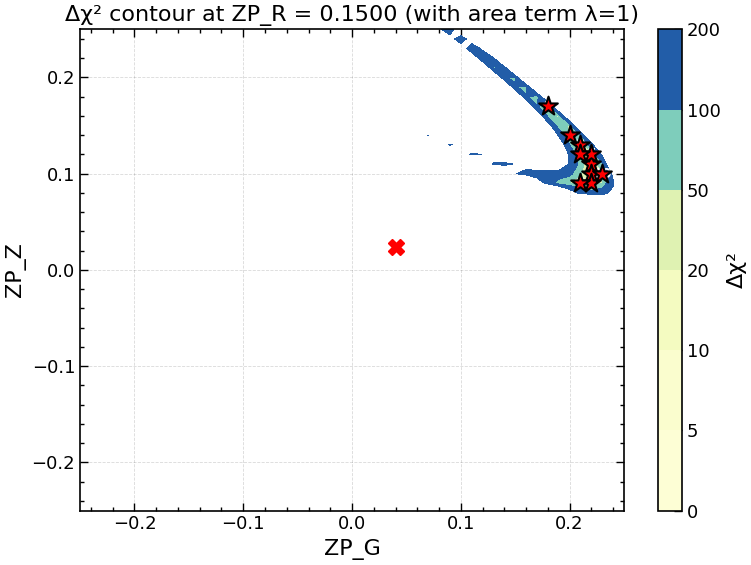


For ZP_R = 0.1400:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.1900       0.1300       20.4446     
2      0.2000       0.1100       20.7244     
3      0.2100       0.1000       24.4970     
4      0.2000       0.1200       25.3177     
5      0.2100       0.0900       26.3309     
6      0.1800       0.1400       38.2893     
7      0.2000       0.0900       40.6499     
8      0.2000       0.0800       44.2012     
9      0.2000       0.1000       45.3693     


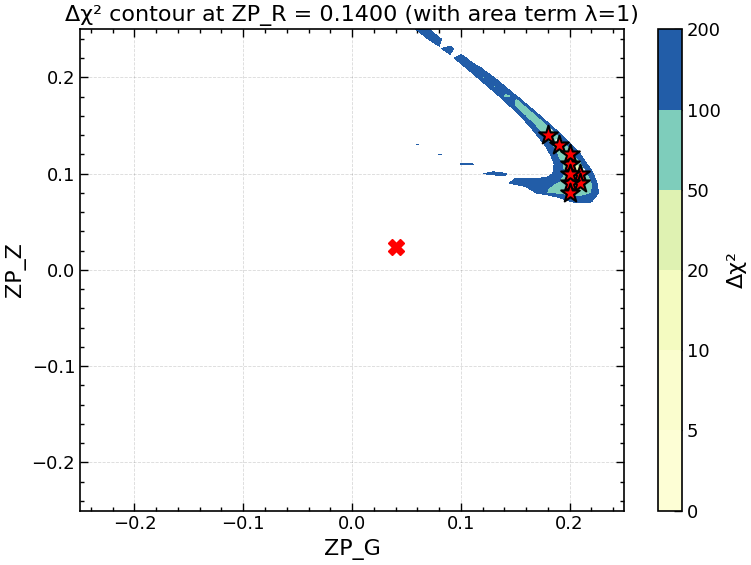


For ZP_R = 0.1300:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.1900       0.1000       23.2004     
2      0.1800       0.1200       32.7950     
3      0.1700       0.1300       37.2898     
4      0.1900       0.0900       38.6184     
5      0.1900       0.0800       39.6215     
6      0.1600       0.1400       45.8170     
7      0.2000       0.0800       48.3727     


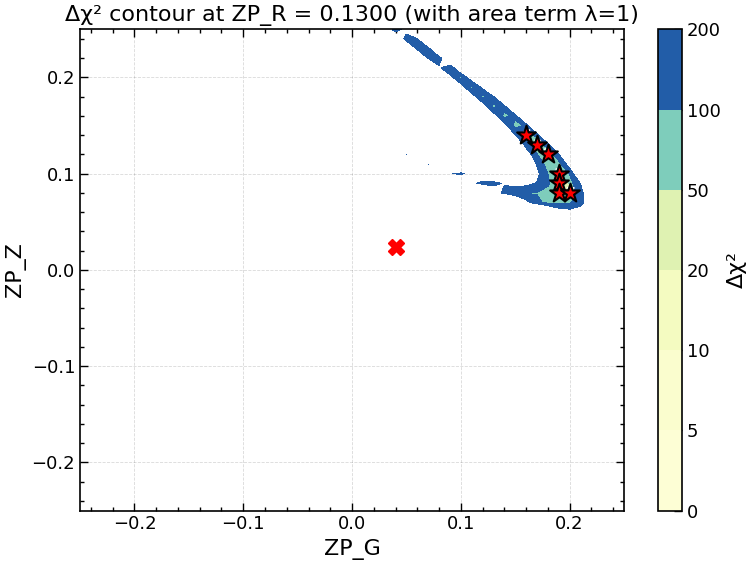


For ZP_R = 0.1200:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.1800       0.0900       32.9111     
2      0.1800       0.0800       38.7194     
3      0.1700       0.1000       42.4323     
4      0.1600       0.1200       43.3822     
5      0.1500       0.1300       44.3624     
6      0.1800       0.0700       46.1087     


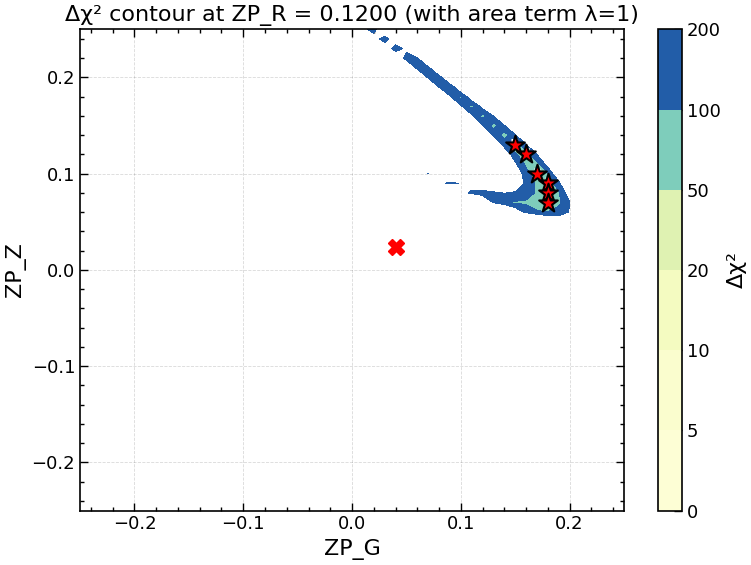


For ZP_R = 0.1100:
Rank   ZP_G         ZP_Z         Δχ²         
---------------------------------------------
1      0.1600       0.0900       42.8970     
2      0.1700       0.0700       48.0833     


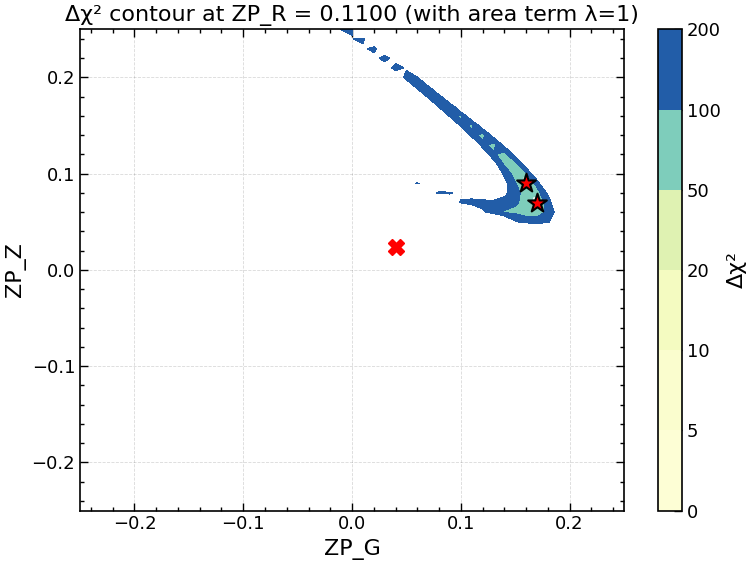

In [ ]:
chi_square_lambda[1]

chi = chi_square_lambda[1]['chi_square_grid'] - np.nanmin(chi_square_lambda[1]['chi_square_grid'])
grid = grid_values

# Find global 200 minimum chi-square values
min_200_indices = np.argsort(chi.ravel())[:100]
min_200_values = chi.ravel()[min_200_indices]
min_200_threshold = min_200_values[-1]

for k in range(len(grid)):
    slice_2d = chi[:, k, :] 
    slice_2d = np.where(np.isinf(slice_2d), np.nan, slice_2d)
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    
    # Find 5 minimum chi-square values in this slice
    valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
    valid_chi = slice_2d[valid_mask_slice]
    valid_indices = np.where(valid_mask_slice)
    
    if len(valid_chi) > 0:
        n_min = min(10, len(valid_chi))
        min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
        
        min_i = valid_indices[0][min_indices]
        min_j = valid_indices[1][min_indices]
        min_chi_values = valid_chi[min_indices]
        
        # Sort by chi-square value
        sort_order = np.argsort(min_chi_values)
        min_i = min_i[sort_order]
        min_j = min_j[sort_order]
        min_chi_values = min_chi_values[sort_order]
        
        # Check if any of the 5 minima are in top 200 global minima
        if np.any(min_chi_values <= min_200_threshold):

            fig, ax = plt.subplots(figsize=(8, 6))
            cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,200], cmap='YlGnBu')
            plt.colorbar(cs, ax=ax, label='Δχ²')
            plt.plot(true_values[0], true_values[2], 'rX', markersize=12, label='True Values')
            # Plot the 5 minimum points
            for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                if chi_val <= min_200_threshold:
                    ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                            edgecolors='black', linewidths=1.5, zorder=10)
                    ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                        va='center', color='white', fontweight='bold')
            
            ax.set_title(f"Δχ² contour at ZP_R = {grid[k]:.4f} (with area term λ=1)")
            ax.set_xlabel("ZP_G")
            ax.set_ylabel("ZP_Z")
            
            # Print the coordinates of the 5 minima
            print(f"\nFor ZP_R = {grid[k]:.4f}:")
            print(f"{'Rank':<6} {'ZP_G':<12} {'ZP_Z':<12} {'Δχ²':<12}")
            print("-" * 45)
            for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                if chi_val <= min_200_threshold:
                    print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
            
            plt.tight_layout()
            plt.show()

##  RZ plot


For ZP_G = 0.2500:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1700       0.1200       0.0000      
2      0.1900       0.1800       0.3197      
3      0.1700       0.1100       3.4052      
4      0.1800       0.1500       4.3708      
5      0.1700       0.1300       13.0266     
6      0.1800       0.1600       13.2424     
7      0.2200       0.2500       24.5715     
8      0.1800       0.1100       26.7103     
9      0.1900       0.1200       31.0922     
10     0.2000       0.2000       32.4536     


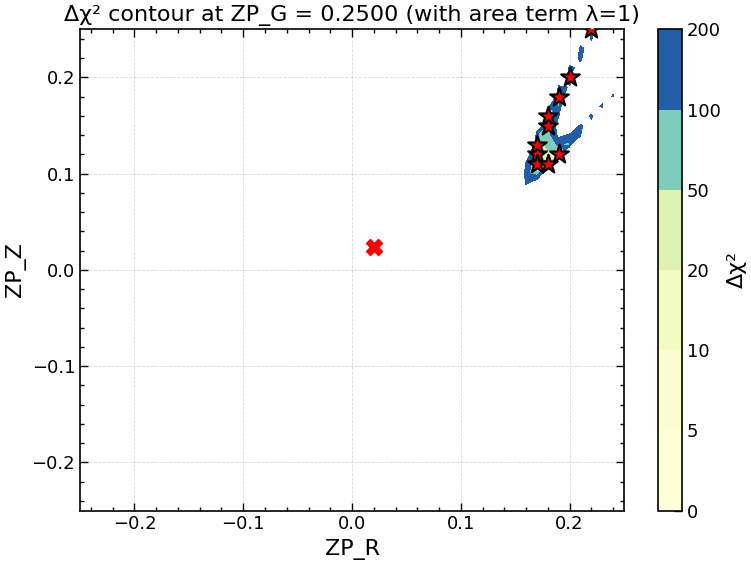


For ZP_G = 0.2400:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1800       0.1700       0.9940      
2      0.1700       0.1400       1.0624      
3      0.1900       0.1900       14.2635     
4      0.1600       0.1100       16.8779     
5      0.1700       0.1100       22.7071     
6      0.1700       0.1300       23.9252     
7      0.1600       0.1000       23.9532     
8      0.1700       0.1200       38.6043     
9      0.1700       0.1500       43.0360     
10     0.1600       0.1200       43.8766     


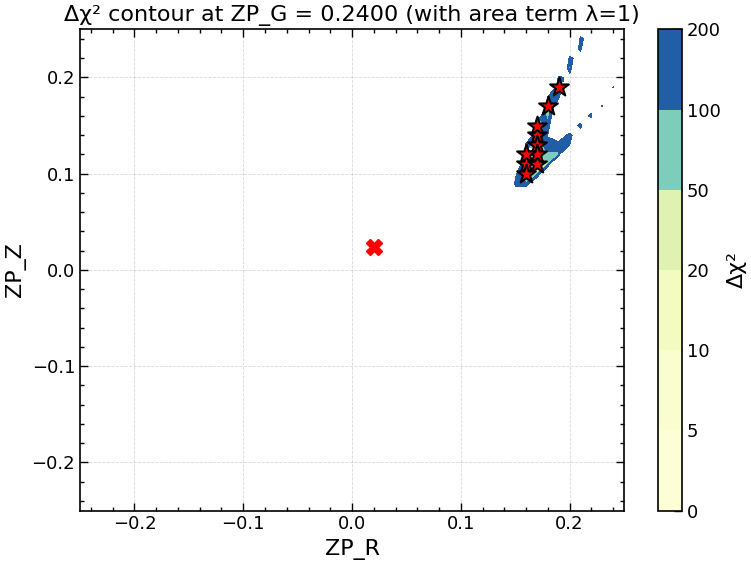


For ZP_G = 0.2300:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1800       0.1800       5.7852      
2      0.1600       0.1300       9.4690      
3      0.1600       0.1200       13.5655     
4      0.1700       0.1600       16.8727     
5      0.1600       0.1000       22.8487     
6      0.1600       0.1100       24.5289     
7      0.1700       0.1500       24.6548     
8      0.1900       0.2000       31.4501     
9      0.1500       0.1000       42.5326     
10     0.1700       0.1100       45.8519     


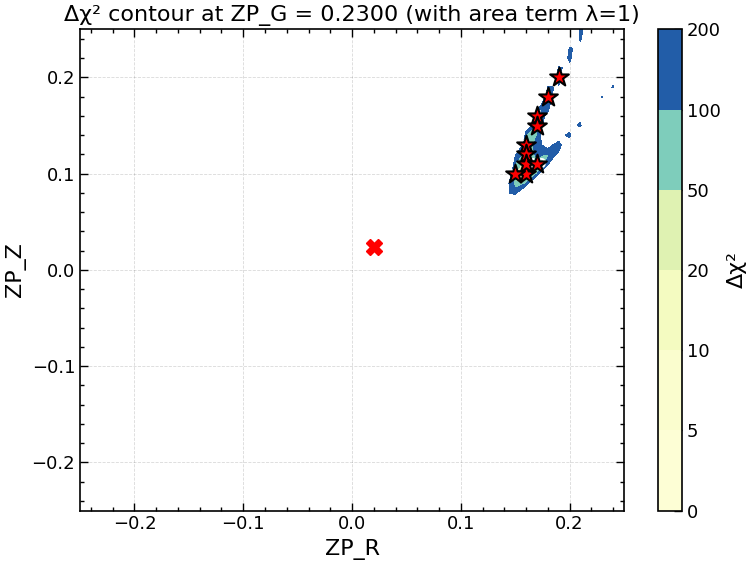


For ZP_G = 0.2200:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1700       0.1700       10.4840     
2      0.1500       0.1100       10.6375     
3      0.1600       0.1400       13.7453     
4      0.1800       0.1900       17.5823     
5      0.1500       0.1000       17.6064     
6      0.1500       0.1200       27.0228     
7      0.1500       0.0900       30.1188     
8      0.1600       0.1000       36.1396     
9      0.1900       0.2100       39.3506     
10     0.1600       0.1500       42.7288     


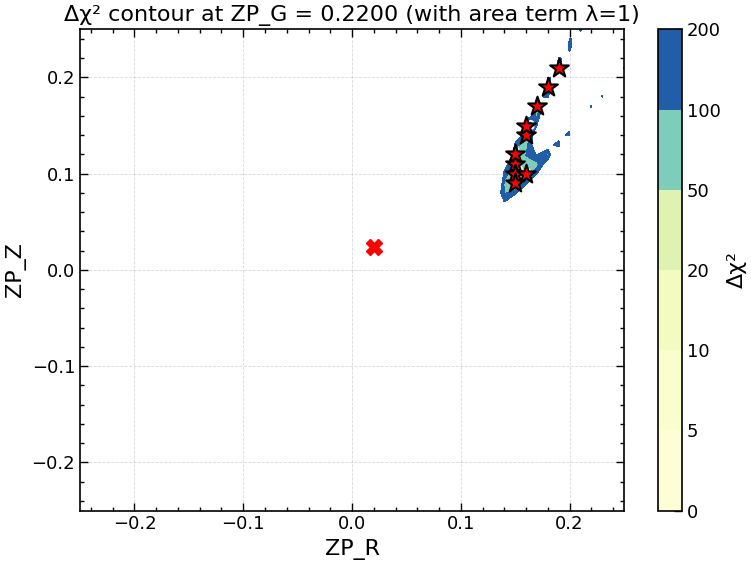


For ZP_G = 0.2100:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1500       0.1300       12.0396     
2      0.1700       0.1800       15.8989     
3      0.1800       0.2000       22.0754     
4      0.1400       0.1000       24.4970     
5      0.1600       0.1600       25.4426     
6      0.1400       0.0900       26.3309     
7      0.1500       0.1200       29.7975     
8      0.1500       0.0900       31.7284     
9      0.1600       0.1500       42.6183     
10     0.1900       0.2200       45.3101     


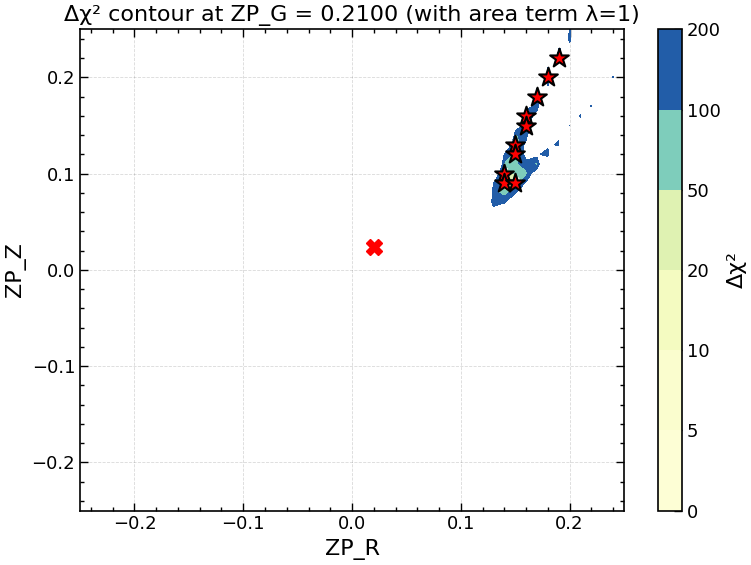


For ZP_G = 0.2000:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1700       0.1900       18.7254     
2      0.1400       0.1100       20.7244     
3      0.1500       0.1400       23.6134     
4      0.1600       0.1700       24.9425     
5      0.1400       0.1200       25.3177     
6      0.1800       0.2100       28.4495     
7      0.1400       0.0900       40.6499     
8      0.1900       0.2300       43.2391     
9      0.1500       0.0900       43.6395     
10     0.1400       0.0800       44.2012     


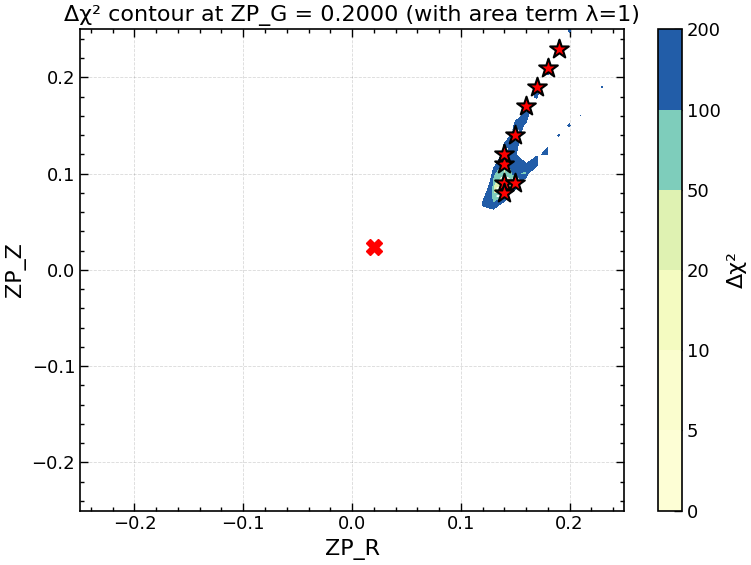


For ZP_G = 0.1900:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1400       0.1300       20.4446     
2      0.1300       0.1000       23.2004     
3      0.1700       0.2000       25.3896     
4      0.1600       0.1800       27.0318     
5      0.1800       0.2200       29.9594     
6      0.1300       0.0900       38.6184     
7      0.1300       0.0800       39.6215     
8      0.1900       0.2400       39.9867     
9      0.1500       0.1600       42.8152     


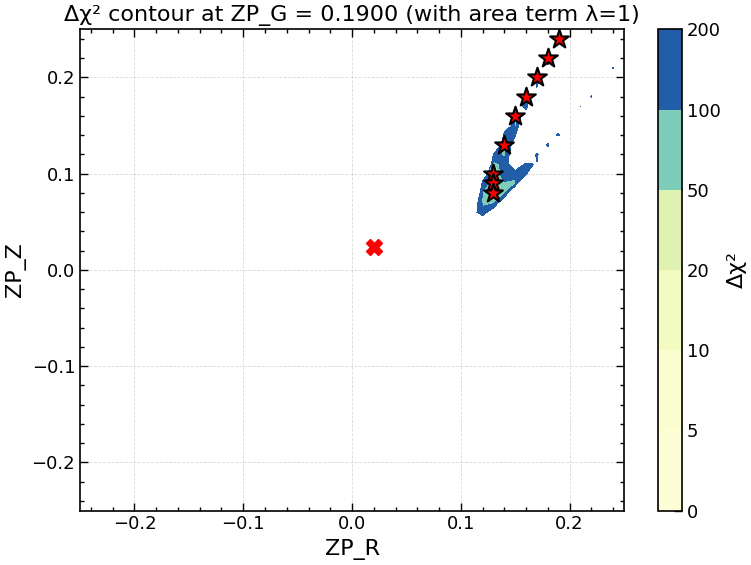


For ZP_G = 0.1800:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1700       0.2100       30.6682     
2      0.1300       0.1200       32.7950     
3      0.1200       0.0900       32.9111     
4      0.1600       0.1900       34.4602     
5      0.1800       0.2300       34.7192     
6      0.1400       0.1400       38.2893     
7      0.1200       0.0800       38.7194     
8      0.1900       0.2500       39.9085     
9      0.1500       0.1700       42.0687     
10     0.1200       0.0700       46.1087     


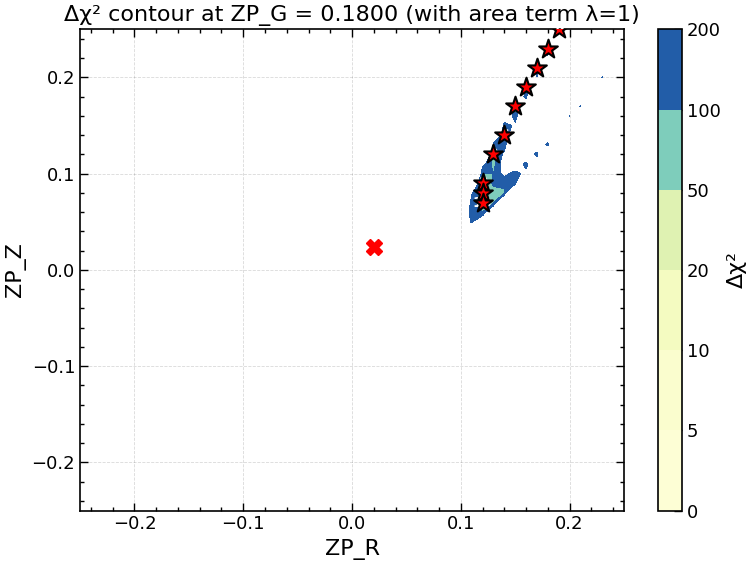


For ZP_G = 0.1700:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1300       0.1300       37.2898     
2      0.1700       0.2200       40.3509     
3      0.1800       0.2400       40.5561     
4      0.1200       0.1000       42.4323     
5      0.1600       0.2000       42.8043     
6      0.1100       0.0700       48.0833     


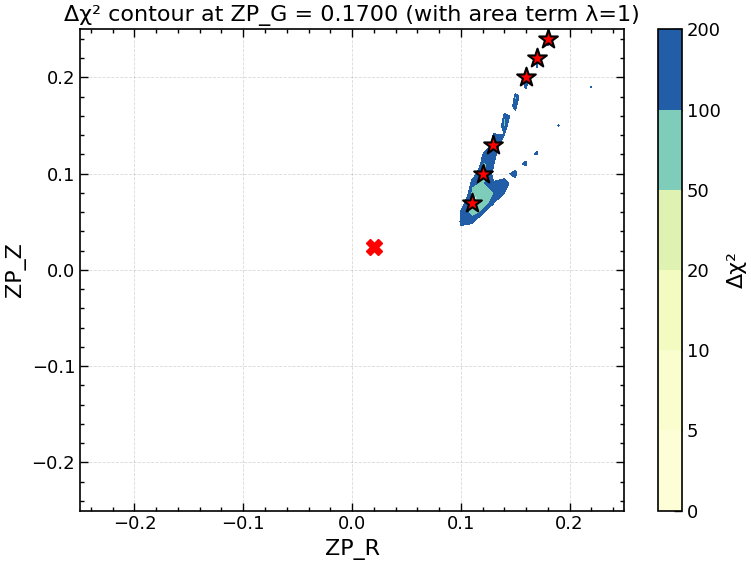


For ZP_G = 0.1600:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1100       0.0900       42.8970     
2      0.1200       0.1200       43.3822     
3      0.1300       0.1400       45.8170     


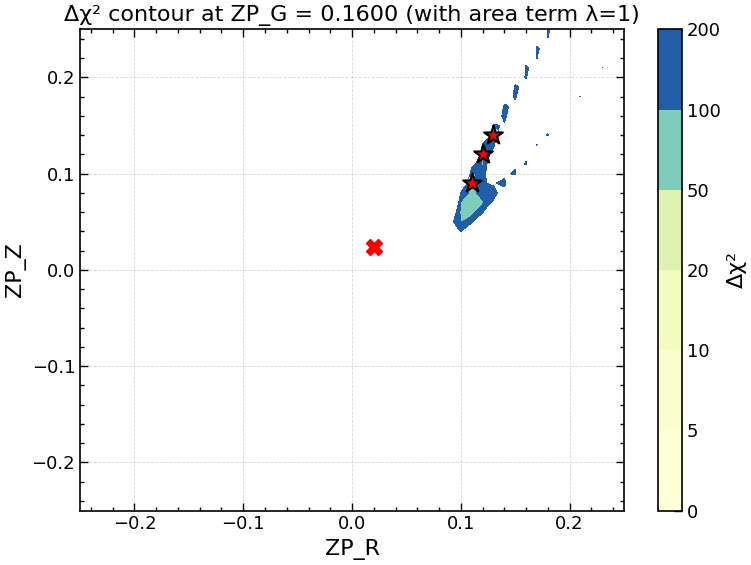


For ZP_G = 0.1500:
Rank   ZP_R         ZP_Z         Δχ²         
---------------------------------------------
1      0.1200       0.1300       44.3624     


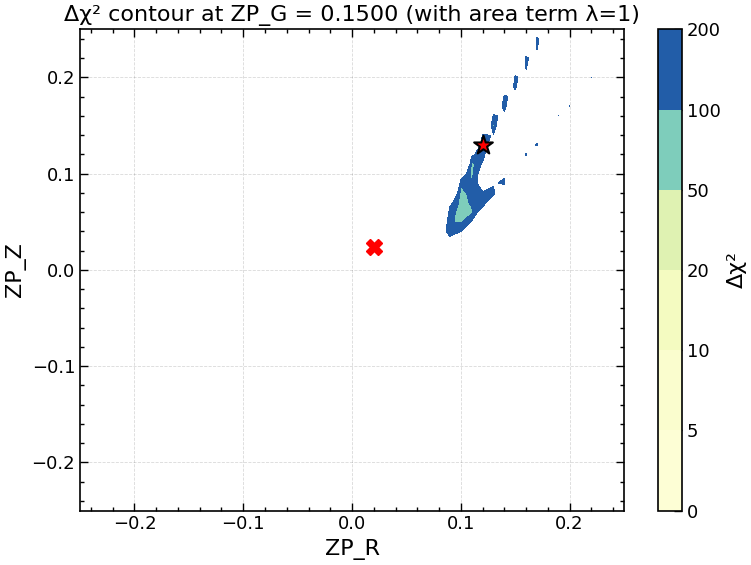

In [ ]:

for k in range(len(grid)):
        slice_2d = chi[k,: , :] 
        slice_2d = np.where(np.isinf(slice_2d),np.nan, slice_2d)
        X, Y = np.meshgrid(grid, grid, indexing='ij')
        
        # Find 5 minimum chi-square values in this slice
        valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
        valid_chi = slice_2d[valid_mask_slice]
        valid_indices = np.where(valid_mask_slice)
        
        if len(valid_chi) > 0:
            n_min = min(10, len(valid_chi))
            min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
            
            min_i = valid_indices[0][min_indices]
            min_j = valid_indices[1][min_indices]
            min_chi_values = valid_chi[min_indices]
            
            # Sort by chi-square value
            sort_order = np.argsort(min_chi_values)
            min_i = min_i[sort_order]
            min_j = min_j[sort_order]
            min_chi_values = min_chi_values[sort_order]
            
            # Check if any of the 5 minima are in top 200 global minima
            if np.any(min_chi_values <= min_200_threshold):

                fig, ax = plt.subplots(figsize=(8, 6))
                cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,200], cmap='YlGnBu')
                plt.colorbar(cs, ax=ax, label='Δχ²')
                plt.plot(true_values[1], true_values[2], 'rX', markersize=12, label='True Values')
                # Plot the 5 minimum points
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                                edgecolors='black', linewidths=1.5, zorder=10)
                        ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                            va='center', color='white', fontweight='bold')
                
                ax.set_title(f"Δχ² contour at ZP_G = {grid[k]:.4f} (with area term λ=1)")
                ax.set_xlabel("ZP_R")
                ax.set_ylabel("ZP_Z")
                
                # Print the coordinates of the 5 minima
                print(f"\nFor ZP_G = {grid[k]:.4f}:")
                print(f"{'Rank':<6} {'ZP_R':<12} {'ZP_Z':<12} {'Δχ²':<12}")
                print("-" * 45)
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
                
                plt.tight_layout()
                plt.show()

##  GR plot


For ZP_Z = 0.2500:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.2200       24.5715     
2      0.1800       0.1900       39.9085     


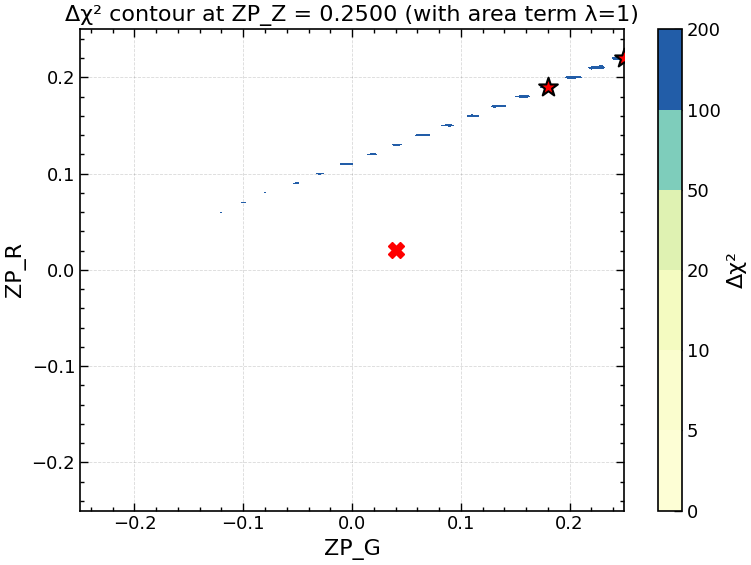


For ZP_Z = 0.2400:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.1900       0.1900       39.9867     
2      0.1700       0.1800       40.5561     
3      0.2400       0.2100       48.6676     


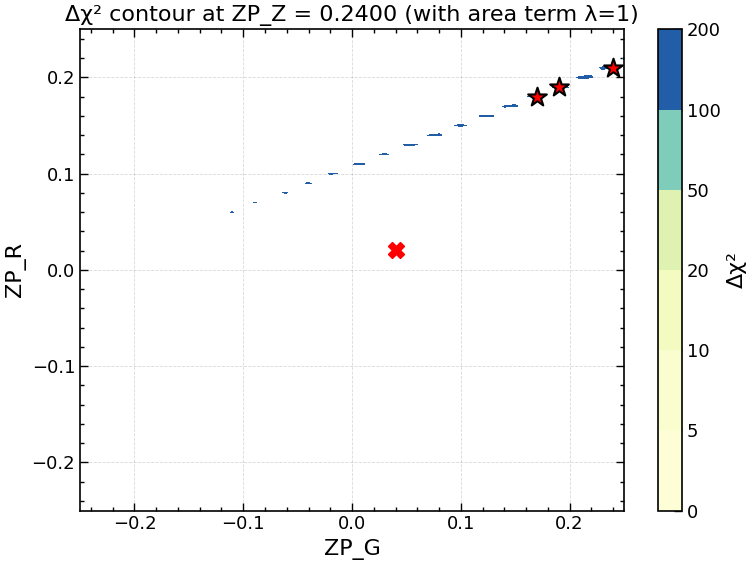


For ZP_Z = 0.2300:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.1800       0.1800       34.7192     
2      0.2500       0.2100       37.7544     
3      0.2000       0.1900       43.2391     


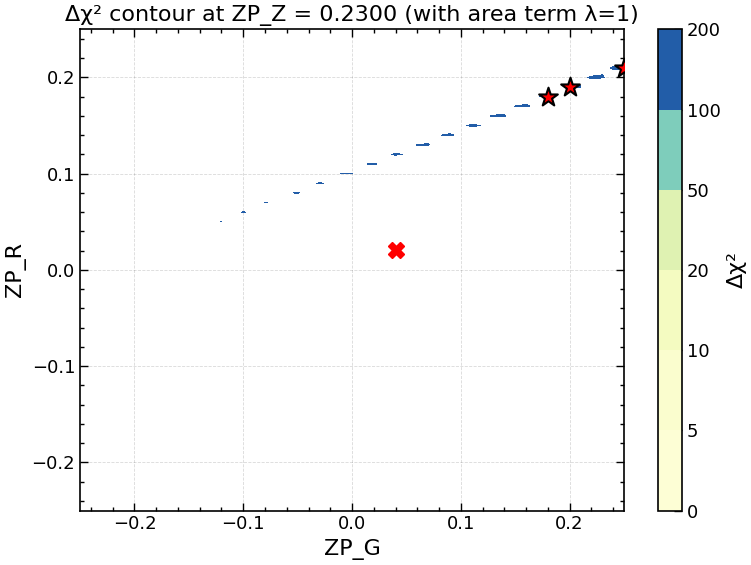


For ZP_Z = 0.2200:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.1900       0.1800       29.9594     
2      0.1700       0.1700       40.3509     
3      0.2100       0.1900       45.3101     


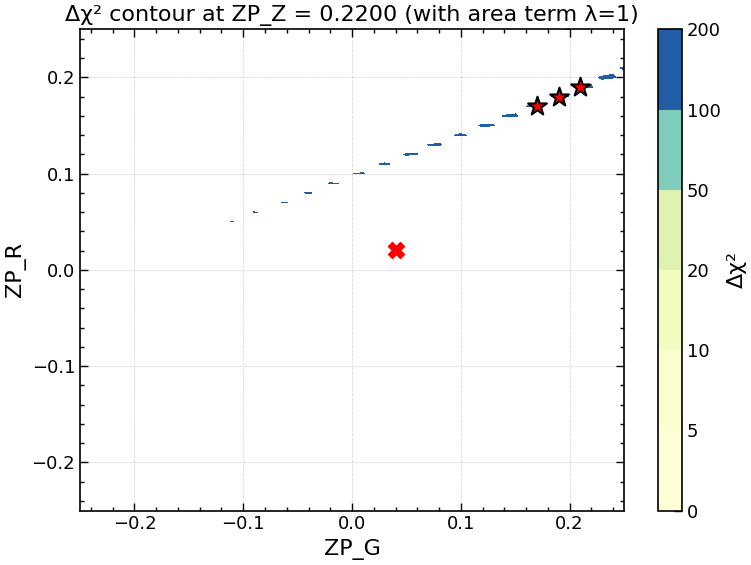


For ZP_Z = 0.2100:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2000       0.1800       28.4495     
2      0.1800       0.1700       30.6682     
3      0.2200       0.1900       39.3506     


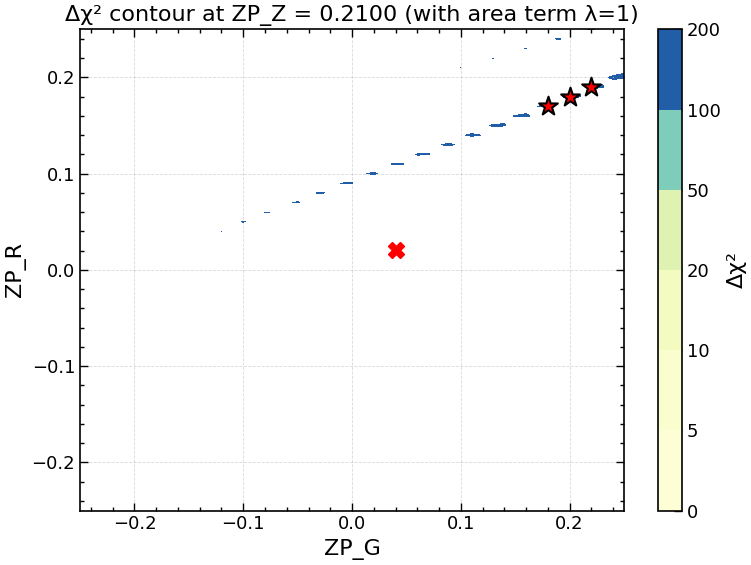


For ZP_Z = 0.2000:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2100       0.1800       22.0754     
2      0.1900       0.1700       25.3896     
3      0.2300       0.1900       31.4501     
4      0.2500       0.2000       32.4536     
5      0.1700       0.1600       42.8043     


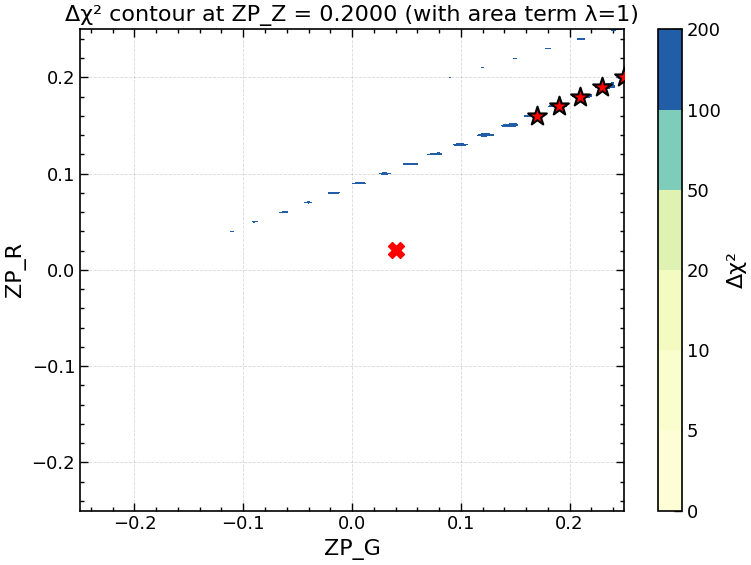


For ZP_Z = 0.1900:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2400       0.1900       14.2635     
2      0.2200       0.1800       17.5823     
3      0.2000       0.1700       18.7254     
4      0.1800       0.1600       34.4602     


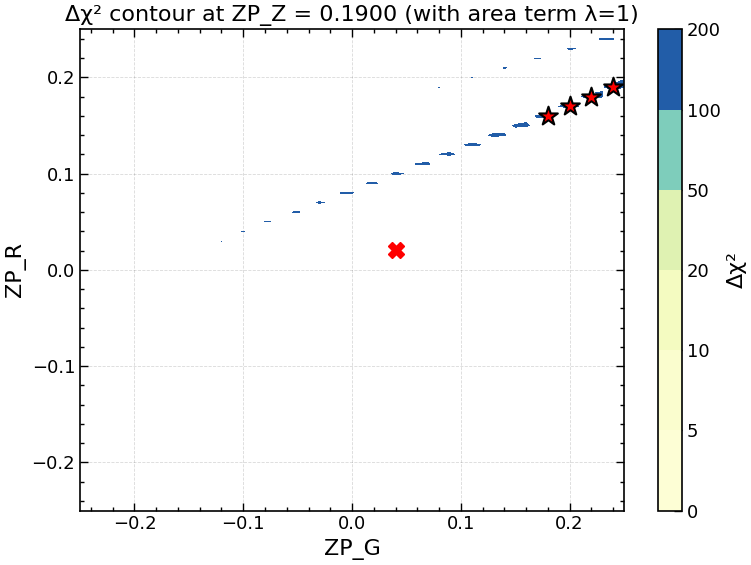


For ZP_Z = 0.1800:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1900       0.3197      
2      0.2300       0.1800       5.7852      
3      0.2100       0.1700       15.8989     
4      0.1900       0.1600       27.0318     


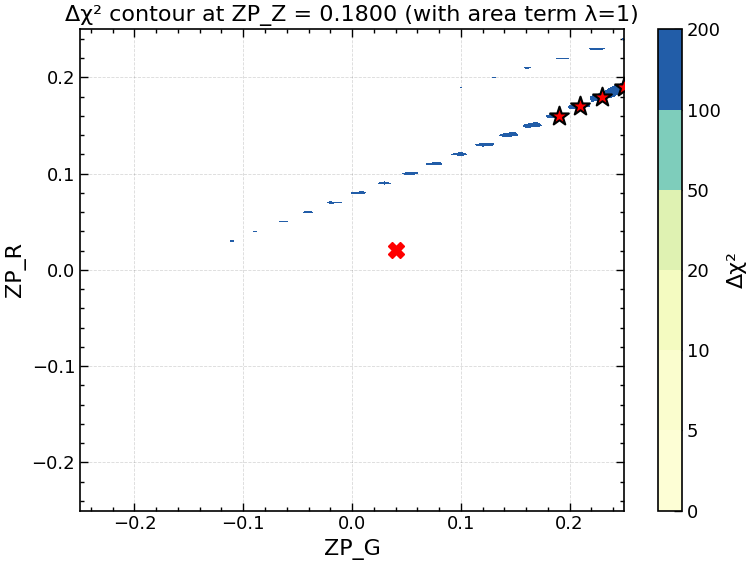


For ZP_Z = 0.1700:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2400       0.1800       0.9940      
2      0.2200       0.1700       10.4840     
3      0.2000       0.1600       24.9425     
4      0.1800       0.1500       42.0687     


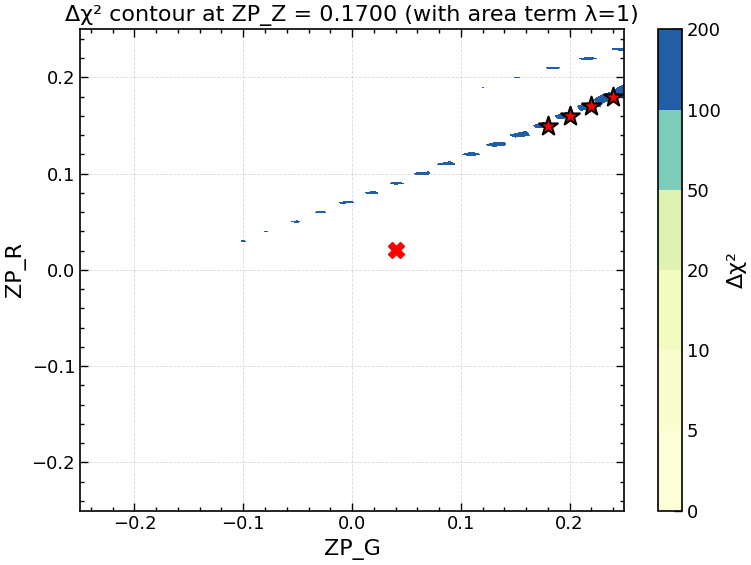


For ZP_Z = 0.1600:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1800       13.2424     
2      0.2300       0.1700       16.8727     
3      0.2100       0.1600       25.4426     
4      0.1900       0.1500       42.8152     
5      0.2400       0.1800       48.5486     


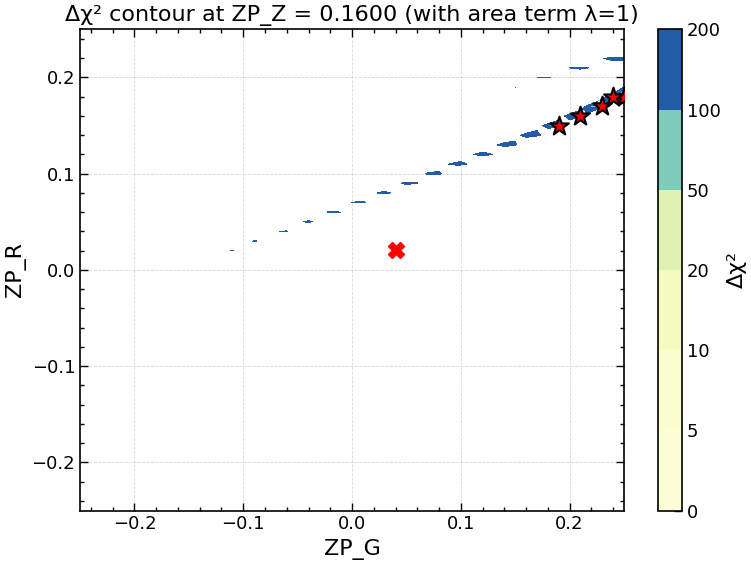


For ZP_Z = 0.1500:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1800       4.3708      
2      0.2300       0.1700       24.6548     
3      0.2100       0.1600       42.6183     
4      0.2200       0.1600       42.7288     
5      0.2400       0.1700       43.0360     
6      0.2000       0.1500       49.5550     


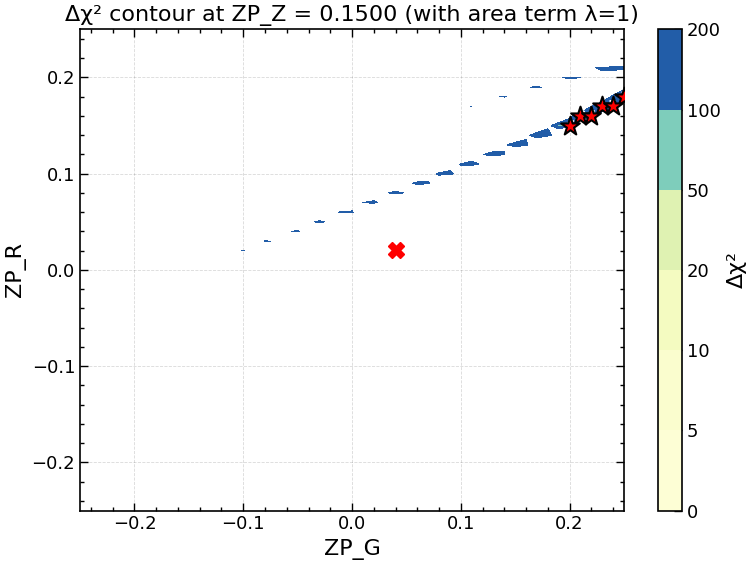


For ZP_Z = 0.1400:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2400       0.1700       1.0624      
2      0.2200       0.1600       13.7453     
3      0.2000       0.1500       23.6134     
4      0.1800       0.1400       38.2893     
5      0.1600       0.1300       45.8170     
6      0.2500       0.1800       46.6301     


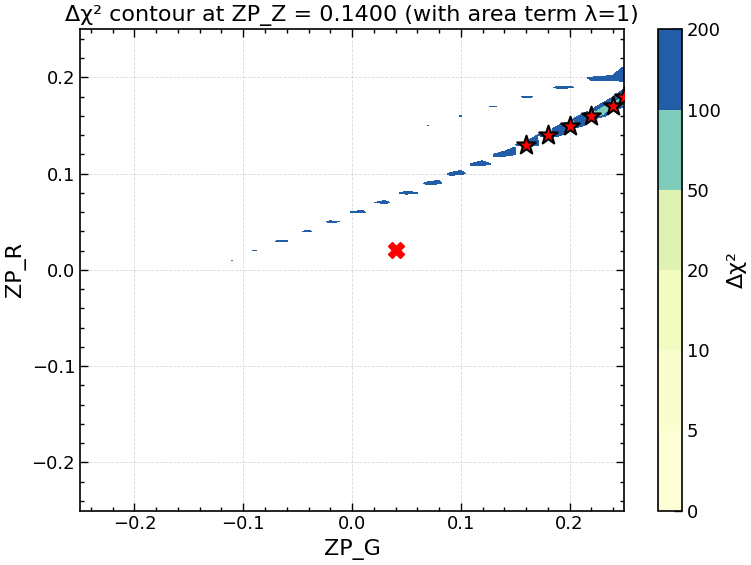


For ZP_Z = 0.1300:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2300       0.1600       9.4690      
2      0.2100       0.1500       12.0396     
3      0.2500       0.1700       13.0266     
4      0.1900       0.1400       20.4446     
5      0.2400       0.1700       23.9252     
6      0.1700       0.1300       37.2898     
7      0.1500       0.1200       44.3624     


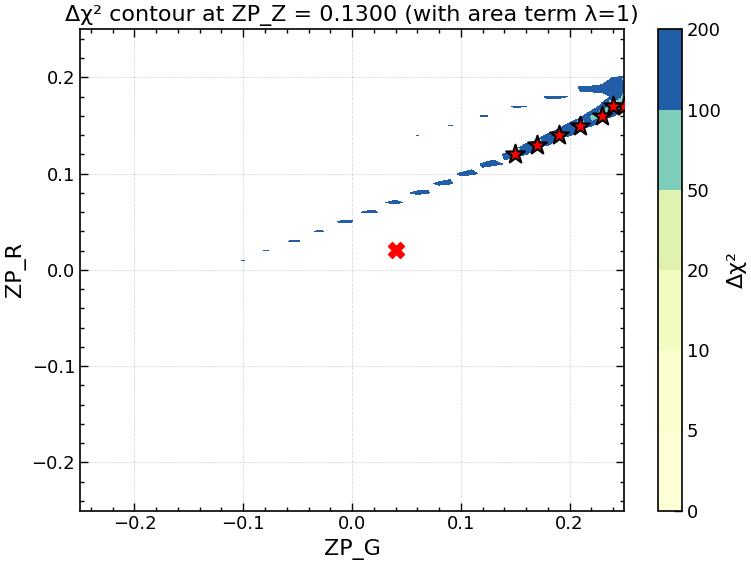


For ZP_Z = 0.1200:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1700       0.0000      
2      0.2300       0.1600       13.5655     
3      0.2000       0.1400       25.3177     
4      0.2200       0.1500       27.0228     
5      0.2100       0.1500       29.7975     
6      0.2500       0.1900       31.0922     
7      0.1800       0.1300       32.7950     
8      0.2500       0.1800       35.6410     
9      0.2400       0.1700       38.6043     
10     0.1600       0.1200       43.3822     


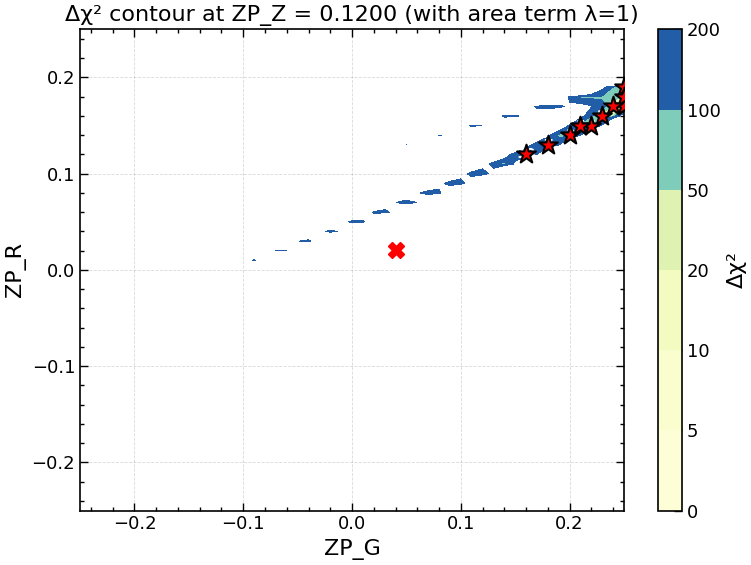


For ZP_Z = 0.1100:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2500       0.1700       3.4052      
2      0.2200       0.1500       10.6375     
3      0.2400       0.1600       16.8779     
4      0.2000       0.1400       20.7244     
5      0.2400       0.1700       22.7071     
6      0.2300       0.1600       24.5289     
7      0.2500       0.1800       26.7103     
8      0.2300       0.1700       45.8519     
9      0.2400       0.1800       46.4445     


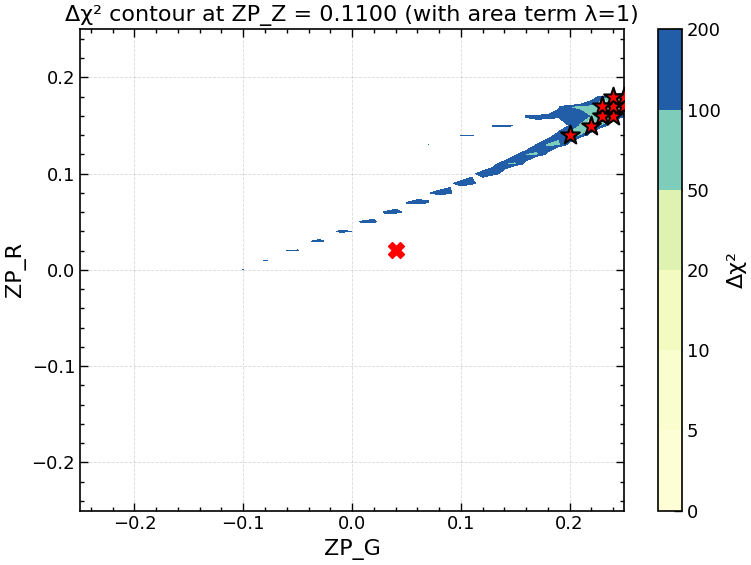


For ZP_Z = 0.1000:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2200       0.1500       17.6064     
2      0.2300       0.1600       22.8487     
3      0.1900       0.1300       23.2004     
4      0.2400       0.1600       23.9532     
5      0.2100       0.1400       24.4970     
6      0.2200       0.1600       36.1396     
7      0.1700       0.1200       42.4323     
8      0.2300       0.1500       42.5326     
9      0.2000       0.1400       45.3693     
10     0.2400       0.1700       49.1284     


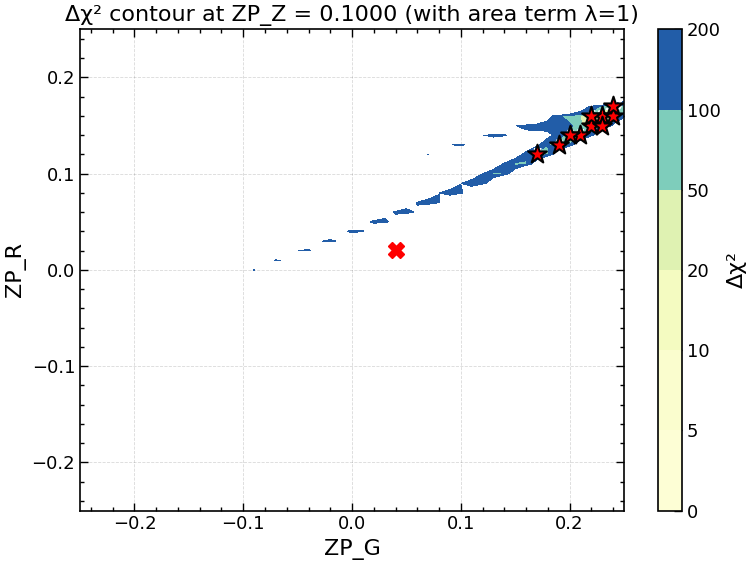


For ZP_Z = 0.0900:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.2100       0.1400       26.3309     
2      0.2200       0.1500       30.1188     
3      0.2100       0.1500       31.7284     
4      0.1800       0.1200       32.9111     
5      0.1900       0.1300       38.6184     
6      0.2000       0.1400       40.6499     
7      0.1600       0.1100       42.8970     
8      0.2000       0.1500       43.6395     


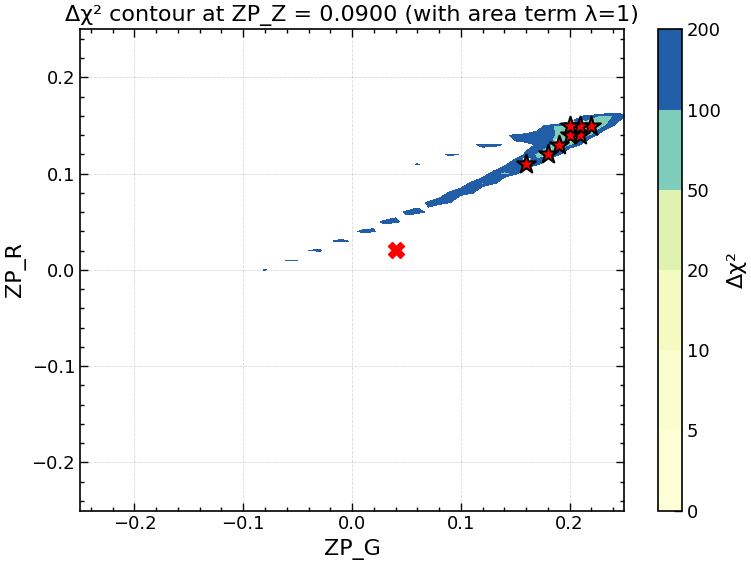


For ZP_Z = 0.0800:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.1800       0.1200       38.7194     
2      0.1900       0.1300       39.6215     
3      0.2000       0.1400       44.2012     
4      0.2000       0.1300       48.3727     


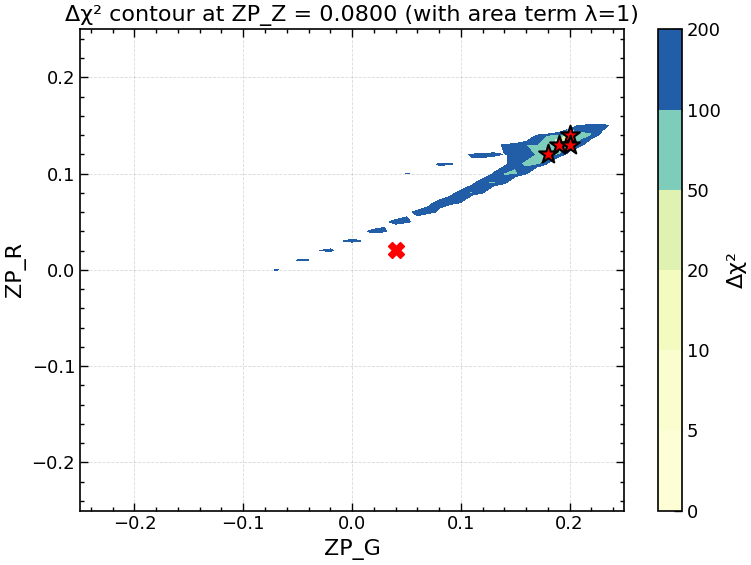


For ZP_Z = 0.0700:
Rank   ZP_G         ZP_R         Δχ²         
---------------------------------------------
1      0.1800       0.1200       46.1087     
2      0.1700       0.1100       48.0833     


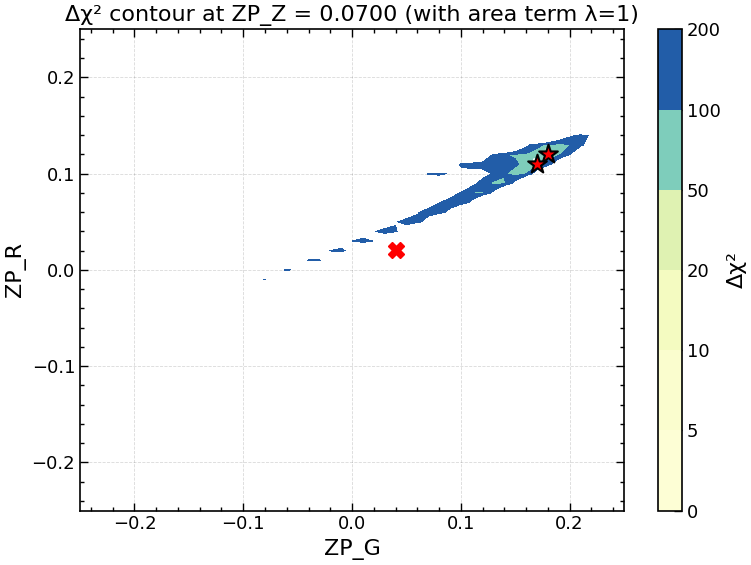

In [ ]:

for k in range(len(grid)):
        slice_2d = chi[:,: , k] 
        slice_2d = np.where(np.isinf(slice_2d),np.nan, slice_2d)
        X, Y = np.meshgrid(grid, grid, indexing='ij')
        
        # Find 5 minimum chi-square values in this slice
        valid_mask_slice = ~np.isnan(slice_2d) & ~np.isinf(slice_2d)
        valid_chi = slice_2d[valid_mask_slice]
        valid_indices = np.where(valid_mask_slice)
        
        if len(valid_chi) > 0:
            n_min = min(10, len(valid_chi))
            min_indices = np.argpartition(valid_chi, n_min - 1)[:n_min]
            
            min_i = valid_indices[0][min_indices]
            min_j = valid_indices[1][min_indices]
            min_chi_values = valid_chi[min_indices]
            
            # Sort by chi-square value
            sort_order = np.argsort(min_chi_values)
            min_i = min_i[sort_order]
            min_j = min_j[sort_order]
            min_chi_values = min_chi_values[sort_order]
            
            # Check if any of the 5 minima are in top 200 global minima
            if np.any(min_chi_values <= min_200_threshold):

                fig, ax = plt.subplots(figsize=(8, 6))
                cs = ax.contourf(X, Y, slice_2d, levels=[0, 5, 10, 20, 50, 100,200], cmap='YlGnBu')
                plt.colorbar(cs, ax=ax, label='Δχ²')
                plt.plot(true_values[0], true_values[1], 'rX', markersize=12, label='True Values')
                # Plot the 5 minimum points
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        ax.scatter(grid[i], grid[j], c='red', s=200, marker='*', 
                                edgecolors='black', linewidths=1.5, zorder=10)
                        ax.text(grid[i], grid[j], f'{idx+1}', fontsize=10, ha='center', 
                            va='center', color='white', fontweight='bold')
                
                ax.set_title(f"Δχ² contour at ZP_Z = {grid[k]:.4f} (with area term λ=1)")

                
                ax.set_xlabel("ZP_G")
                ax.set_ylabel("ZP_R")
                
                # Print the coordinates of the 5 minima
                print(f"\nFor ZP_Z = {grid[k]:.4f}:")
                print(f"{'Rank':<6} {'ZP_G':<12} {'ZP_R':<12} {'Δχ²':<12}")
                print("-" * 45)
                for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
                    if chi_val <= min_200_threshold:
                        print(f"{idx+1:<6} {grid[i]:<12.4f} {grid[j]:<12.4f} {chi_val:<12.4f}")
                
                plt.tight_layout()
                plt.show()

# Contours for varying $\lambda$

In [ ]:
for lambda_ in lambda_array:
    print(f"Lambda: {lambda_}, Min chi-square: {np.min(chi_square_lambda[lambda_]['chi_square_grid']):.2f} at index {np.argmin(chi_square_lambda[lambda_]['chi_square_grid'])}")
    print(f'Grid values at min chi-square: ZP_G={chi_square_lambda[lambda_]["ZP_G"]:.4f}, ZP_R={chi_square_lambda[lambda_]["ZP_R"]:.4f}, ZP_Z={chi_square_lambda[lambda_]["ZP_Z"]:.4f}')

Lambda: 0, Min chi-square: 30.76 at index 72058
Grid values at min chi-square: ZP_G=-0.0200, ZP_R=-0.1000, ZP_Z=-0.2100
Lambda: 0.001, Min chi-square: 54.14 at index 35021
Grid values at min chi-square: ZP_G=0.1200, ZP_R=0.0200, ZP_Z=-0.1000
Lambda: 0.005, Min chi-square: 104.28 at index 3132
Grid values at min chi-square: ZP_G=0.2400, ZP_R=0.1500, ZP_Z=0.0400
Lambda: 0.01, Min chi-square: 139.57 at index 583
Grid values at min chi-square: ZP_G=0.2500, ZP_R=0.1400, ZP_Z=0.0300
Lambda: 0.05, Min chi-square: 193.80 at index 527
Grid values at min chi-square: ZP_G=0.2500, ZP_R=0.1500, ZP_Z=0.0800
Lambda: 0.1, Min chi-square: 209.05 at index 473
Grid values at min chi-square: ZP_G=0.2500, ZP_R=0.1600, ZP_Z=0.1100
Lambda: 1, Min chi-square: 227.52 at index 421
Grid values at min chi-square: ZP_G=0.2500, ZP_R=0.1700, ZP_Z=0.1200
Lambda: 10, Min chi-square: 228.47 at index 313
Grid values at min chi-square: ZP_G=0.2500, ZP_R=0.1900, ZP_Z=0.1800
Lambda: 100000.0, Min chi-square: 351.64 at inde

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packa

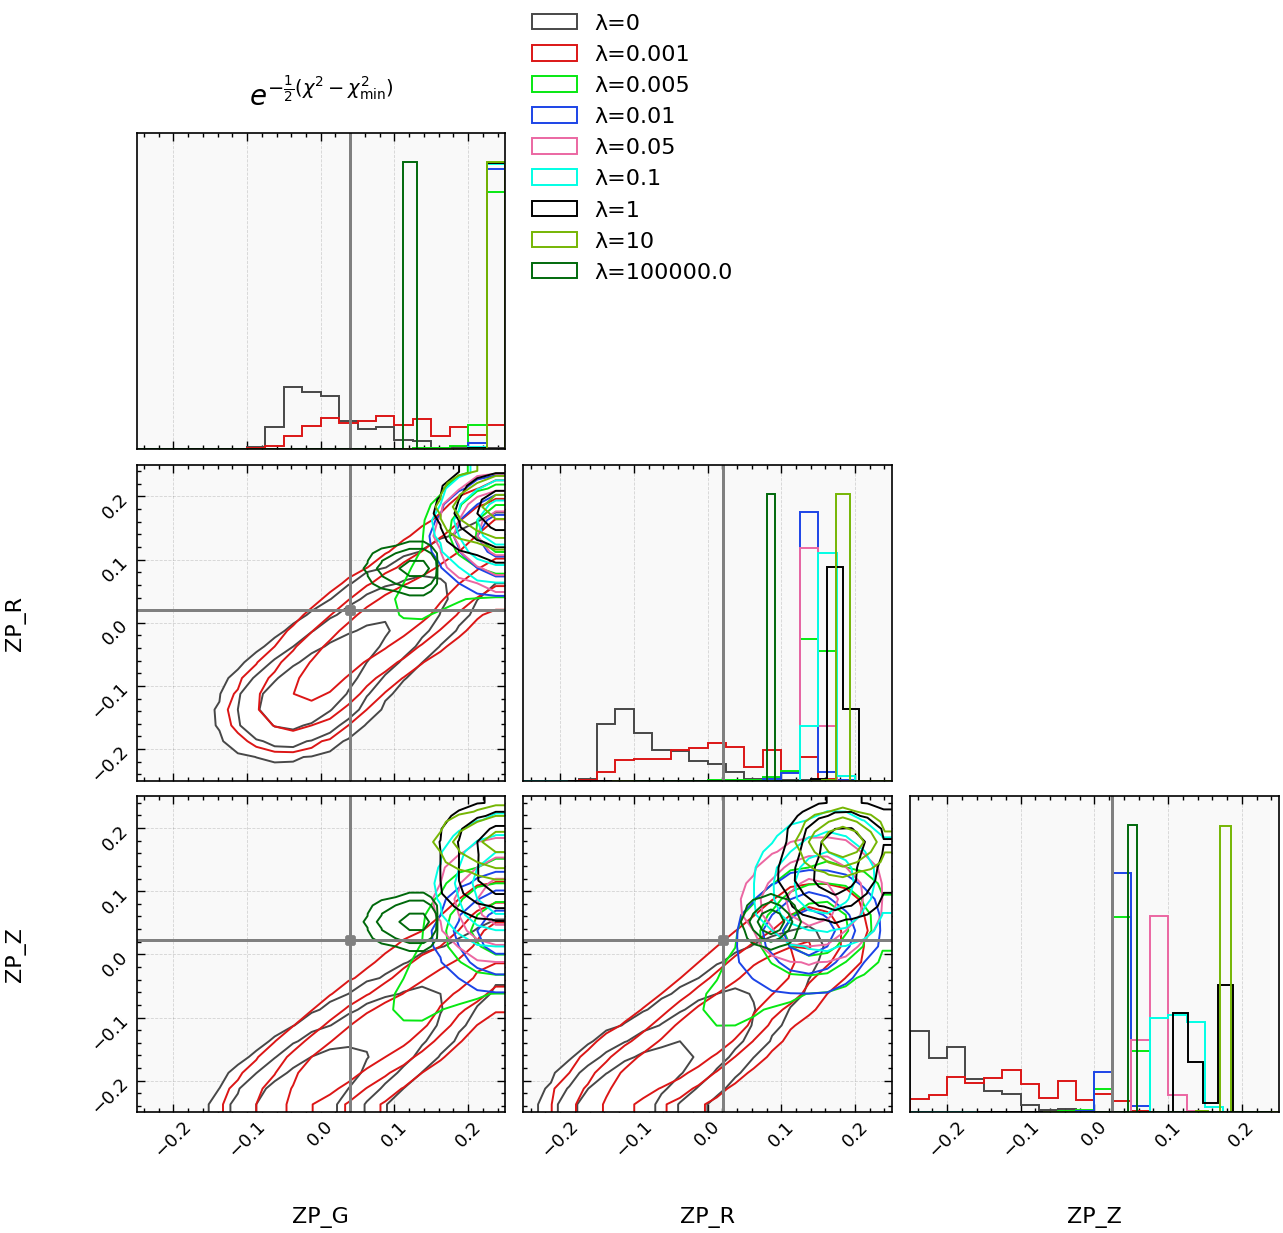

In [ ]:

colors = [
    "#484848",  # deep blue
    "#dc1616",  # violet
    "#07e812", 
    "#1c44e7",  # muted red
     # amber
    "#eb67a2",  # green-teal
        "#00ffe5",  # pink
        "#000000",  # light red-orange
        "#75b604",  
        "#00690B", 
]

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "font.size": 15,
    "axes.linewidth": 1.2,
})
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.15
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.linewidth"] = 0.6
fig = plt.figure(figsize=(14, 12)) 



for idx, lambda_val in enumerate(lambda_array):
    values = chi_square_lambda[lambda_val]
    chi_grid = values['chi_square_grid']
    samples, weights = extract_samples_weights(chi_grid)
    mean_zp = np.average(samples, axis=0, weights=weights)
    cov_zp = np.cov(samples.T, aweights=weights)
    std_zp = np.sqrt(np.diag(cov_zp))
    
    alpha_contour = max(0.05, 0.8 - idx * 0.01)
    alpha_hist = max(0.2, 0.7 - idx * 0.1)

    fig = corner.corner(
        samples,
        weights=weights,
        labels=[r"ZP_G", r"ZP_R", r"ZP_Z"],
        color=colors[idx],
        levels=[0.68, 0.95, 0.997],
        fill_contours=False,
        smooth=1.0,     
        truths=[0.0403, 0.0206, 0.0234],
        truth_color="gray",
        plot_density=False,
        truth_linestyle=":",
        kde=True,
        plot_datapoints=False,
        show_titles=False,
        contour_kwargs={"linewidths": 1.4, "colors": colors[idx], "label": f"λ={lambda_val}"},
        hist_kwargs={"linewidth": 1.4, "color": colors[idx], "label": f"λ={lambda_val}"},
        fig=fig
    )

# Add legend to one of the diagonal subplots
axes = fig.get_axes()
for ax in fig.get_axes():
    ax.set_facecolor("#f9f9f9")  # very light grey background
axes[0].legend(
    loc=(10,-0.5),
    bbox_to_anchor=(1.05, 0.5),
    fontsize=16,
    frameon=False)
    
axes = fig.get_axes()
axes[0].set_title(r"$e^{-\frac{1}{2}(\chi^2 - \chi^2_{\min})}$", fontsize=20, pad=20)
plt.show()


/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


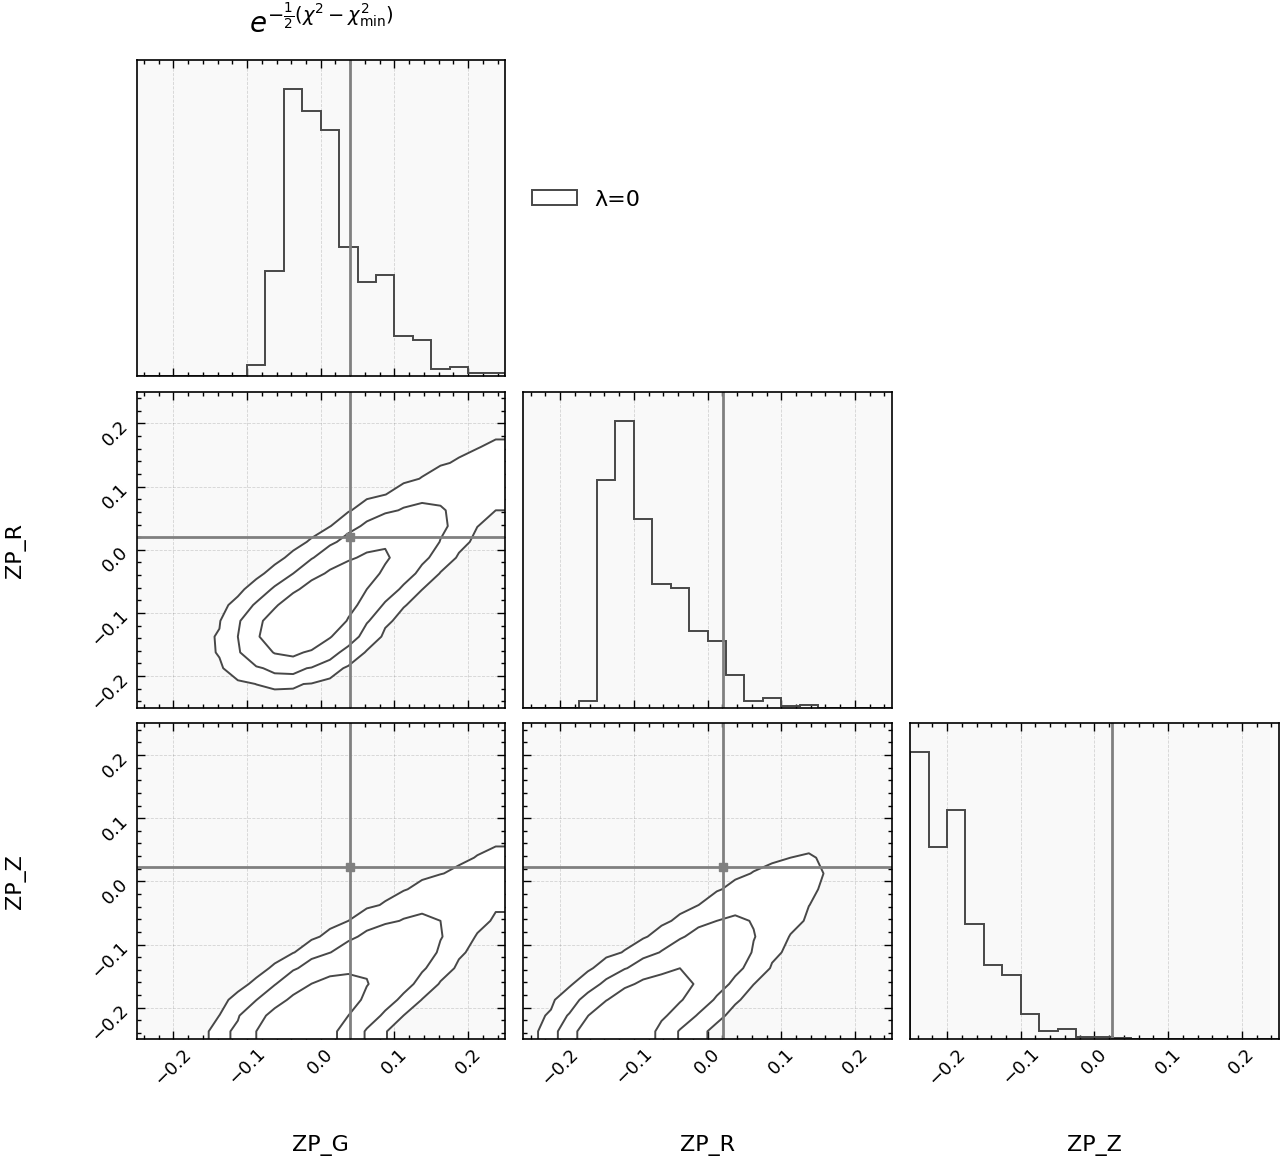

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


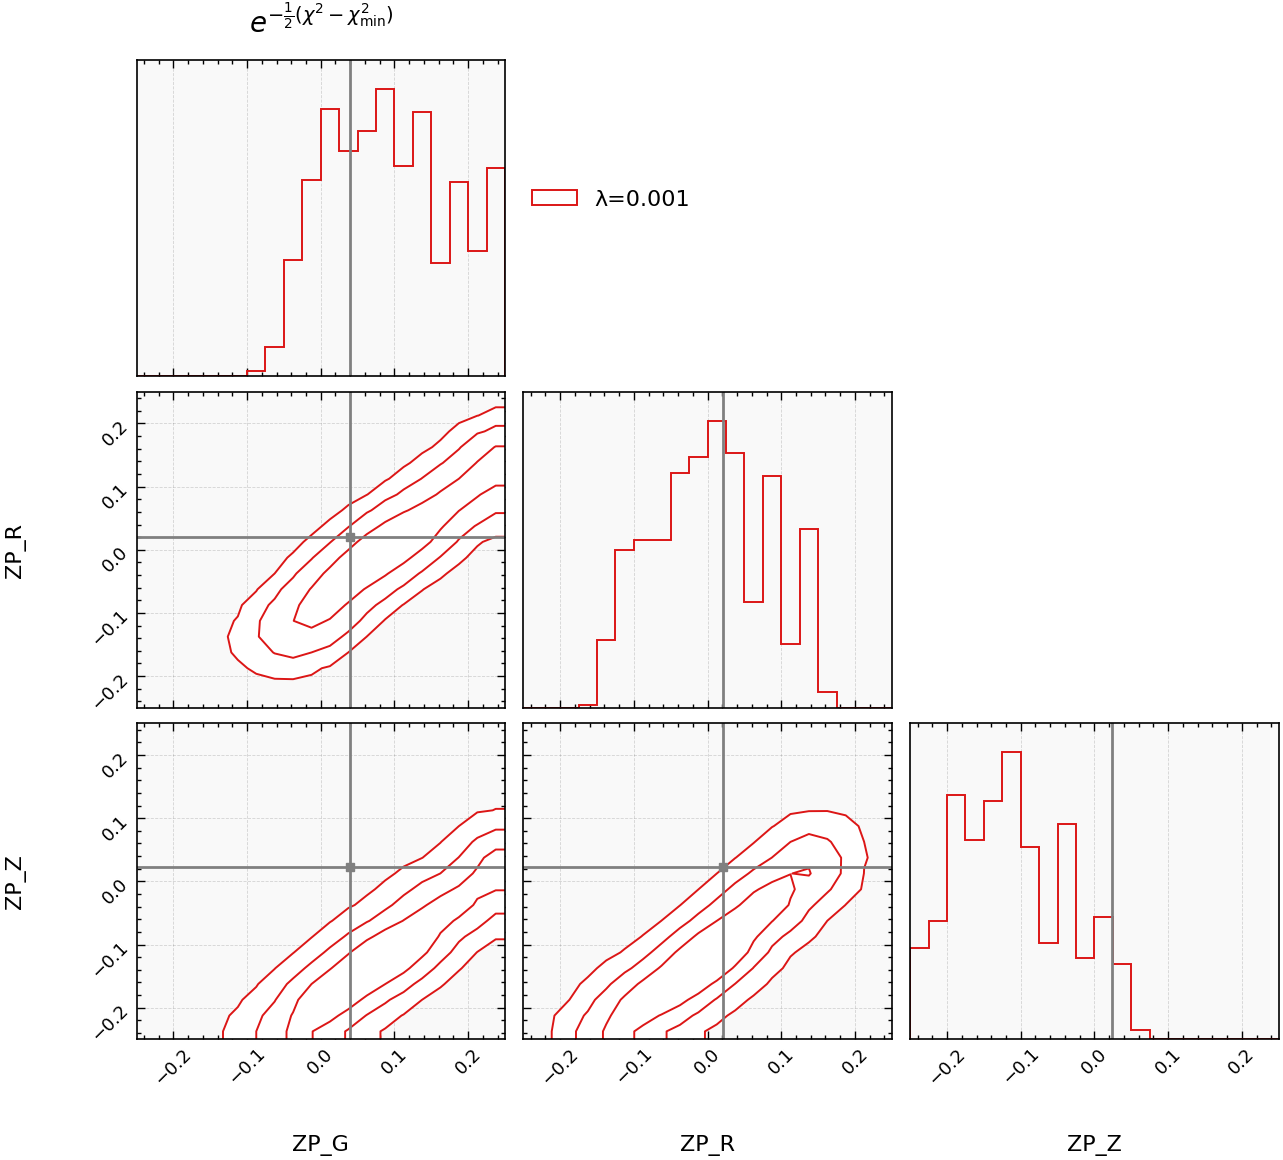

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


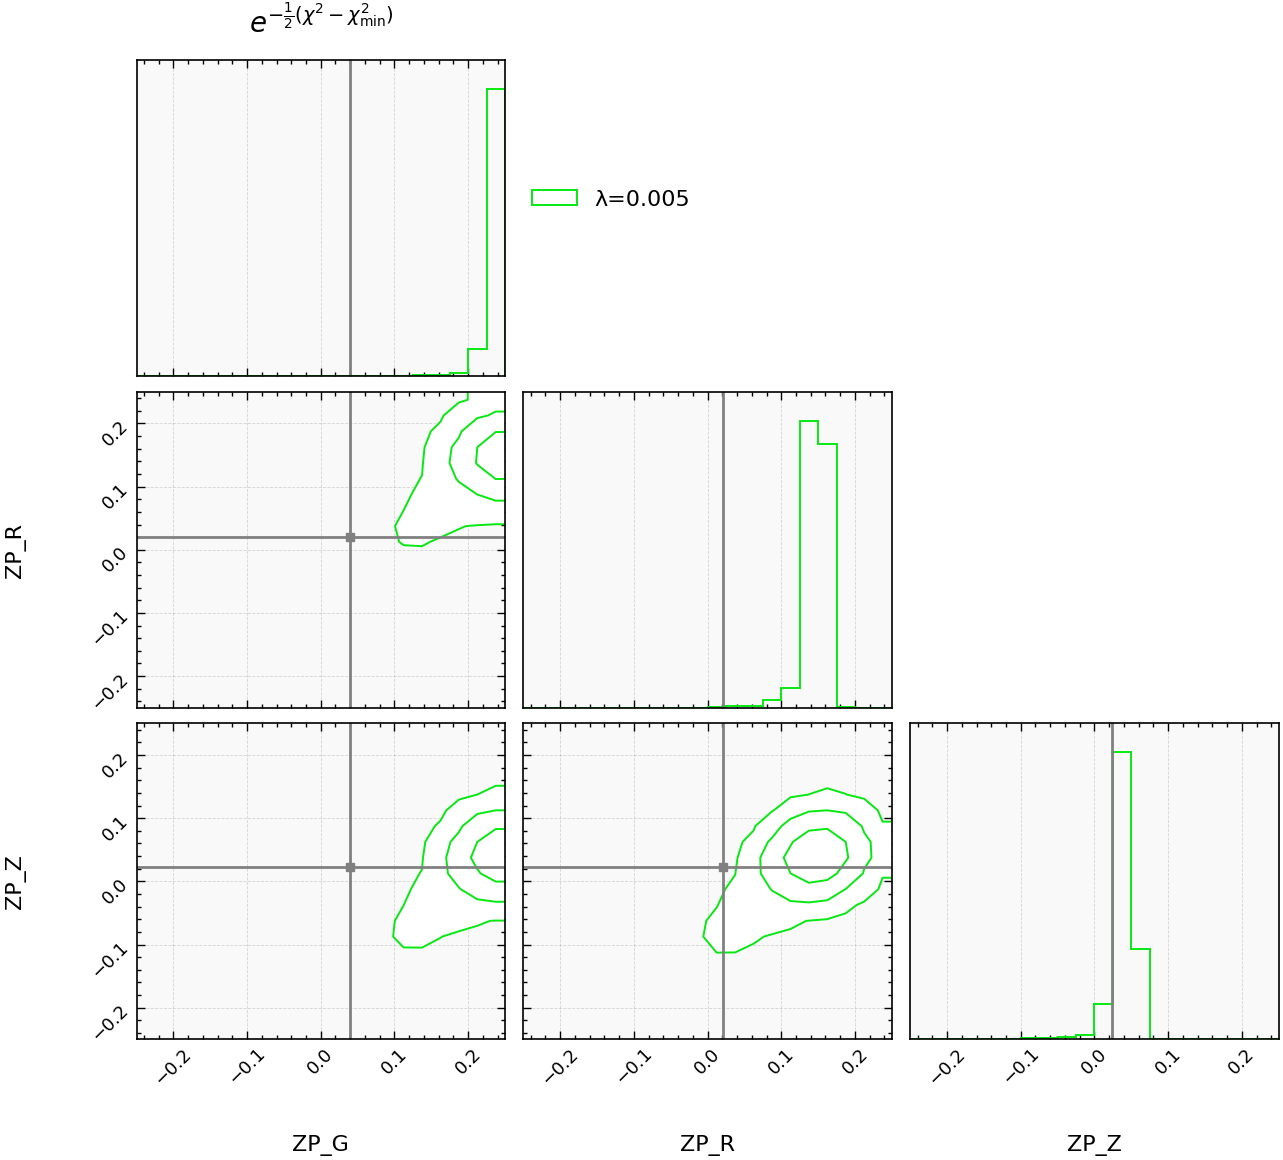

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


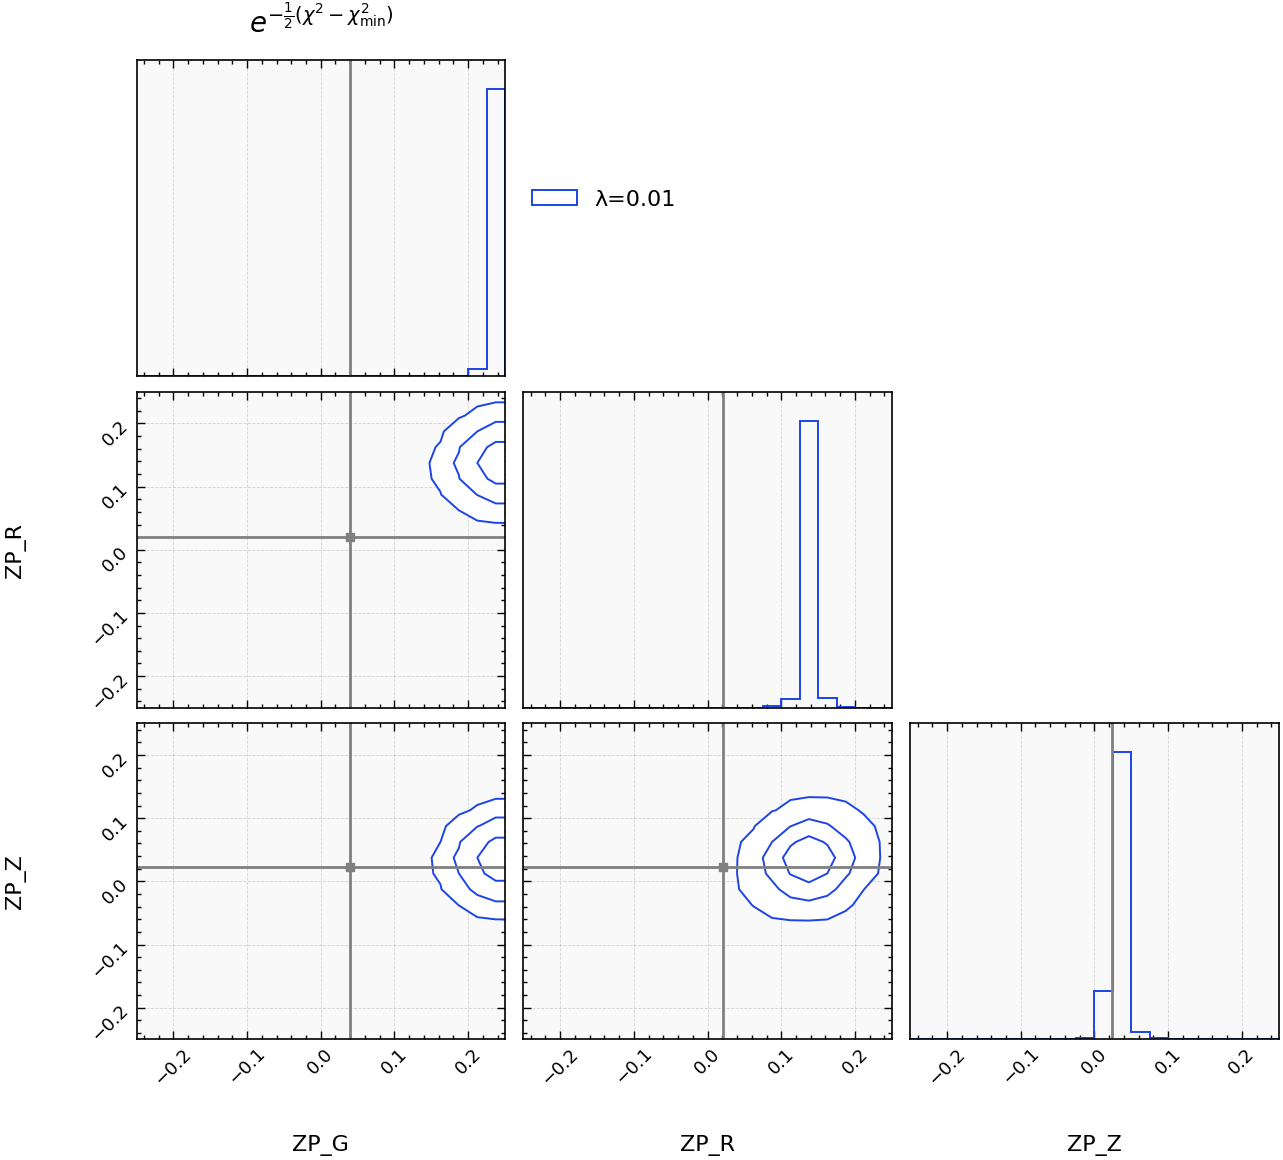

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


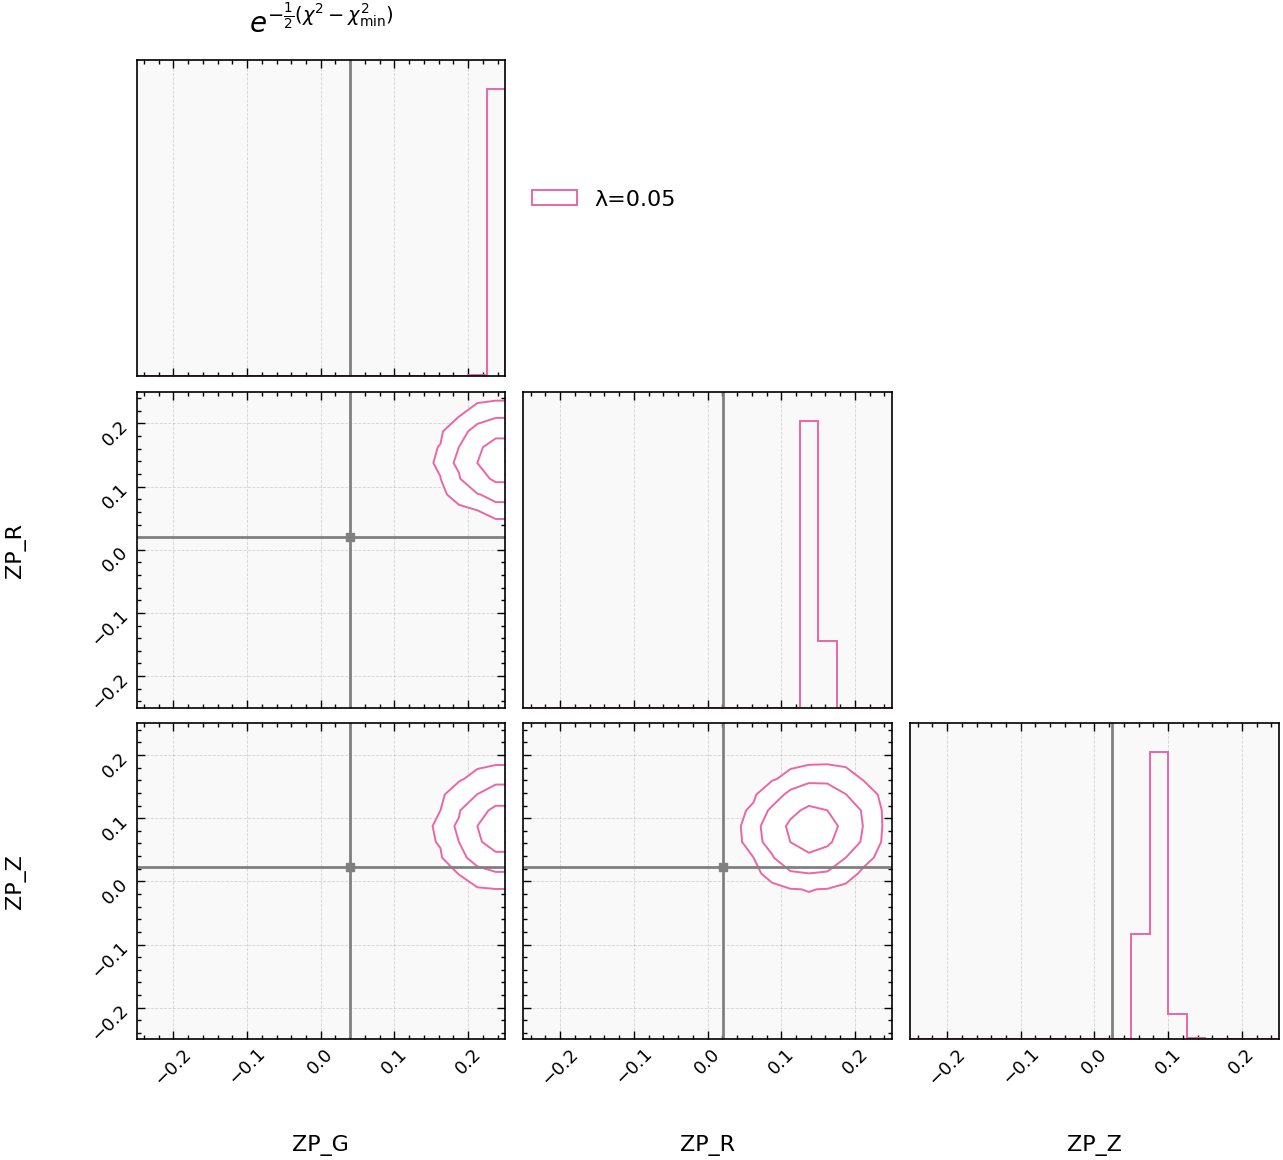

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


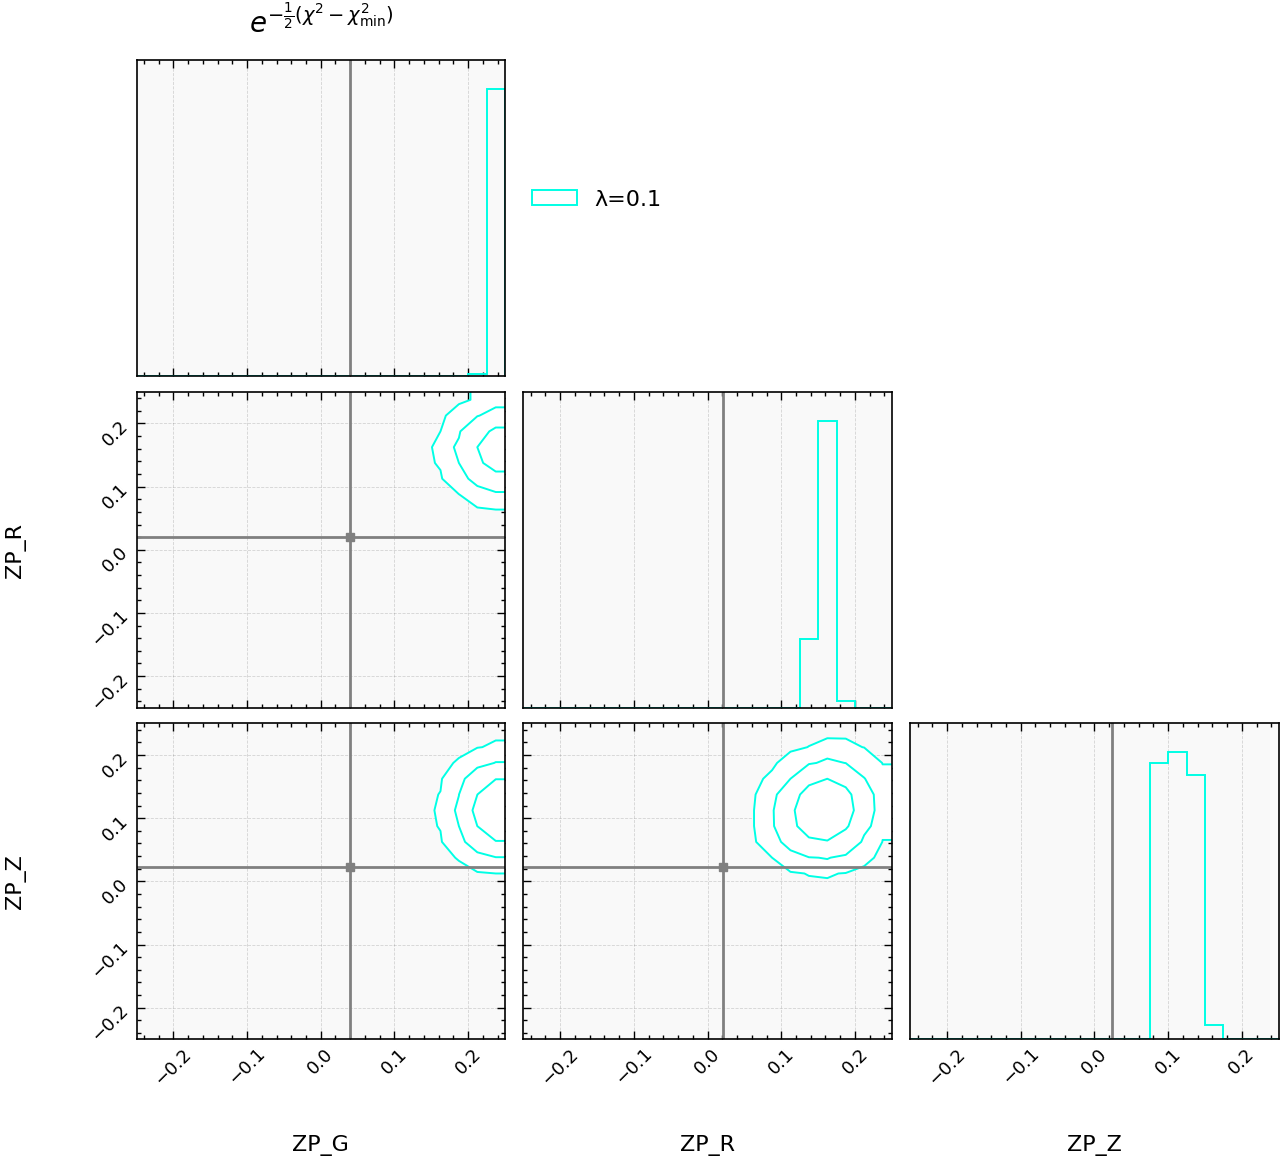

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


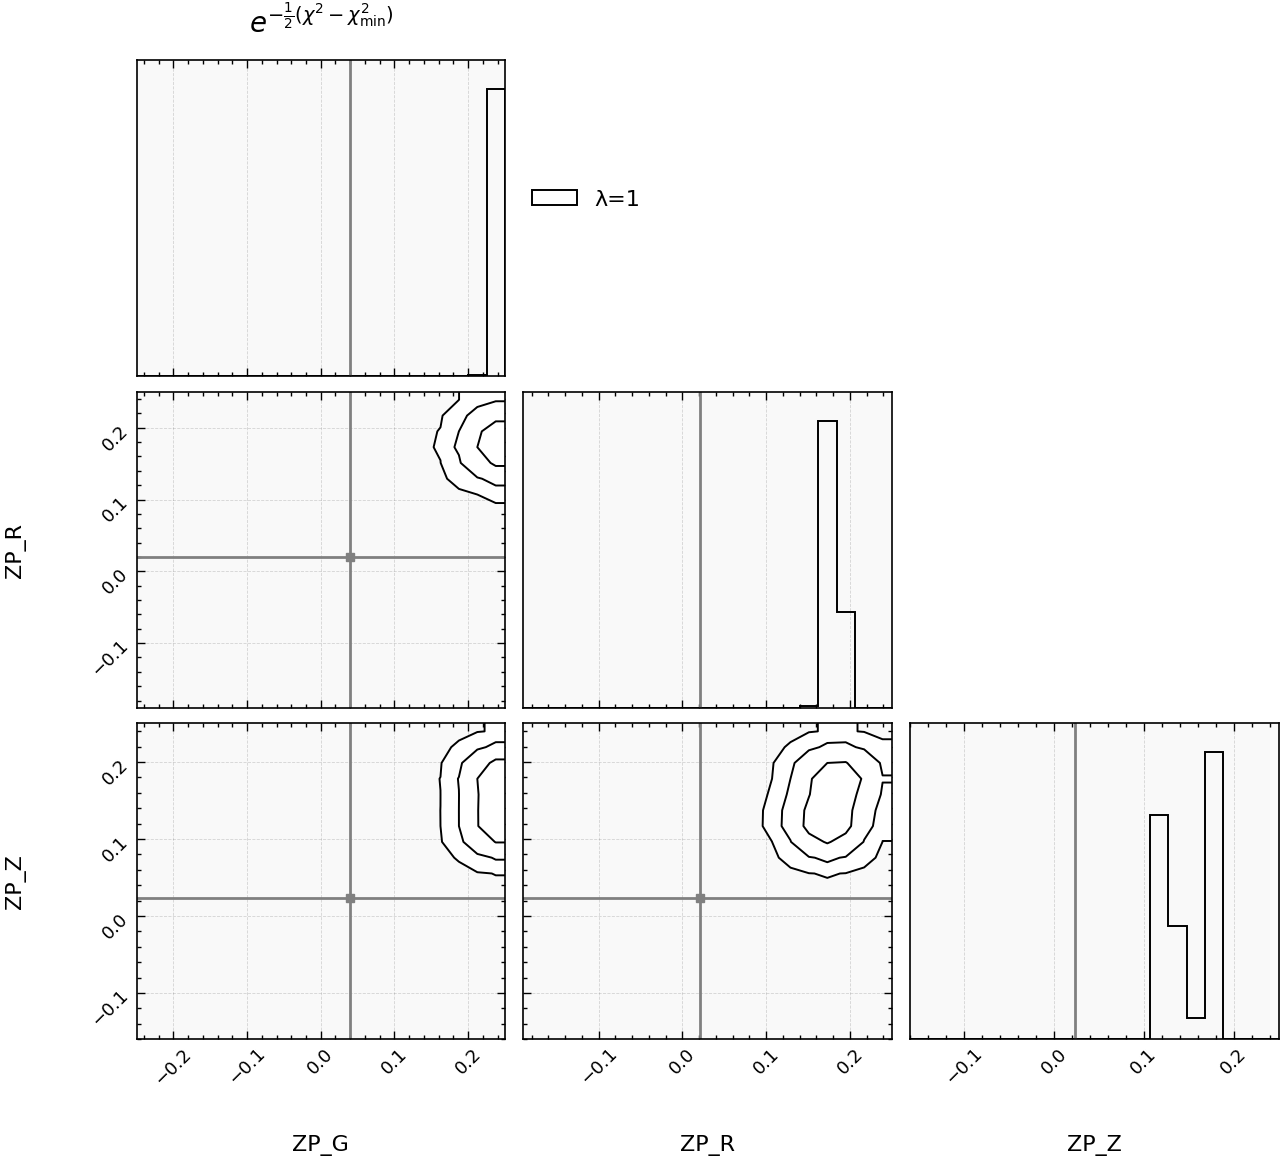

/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


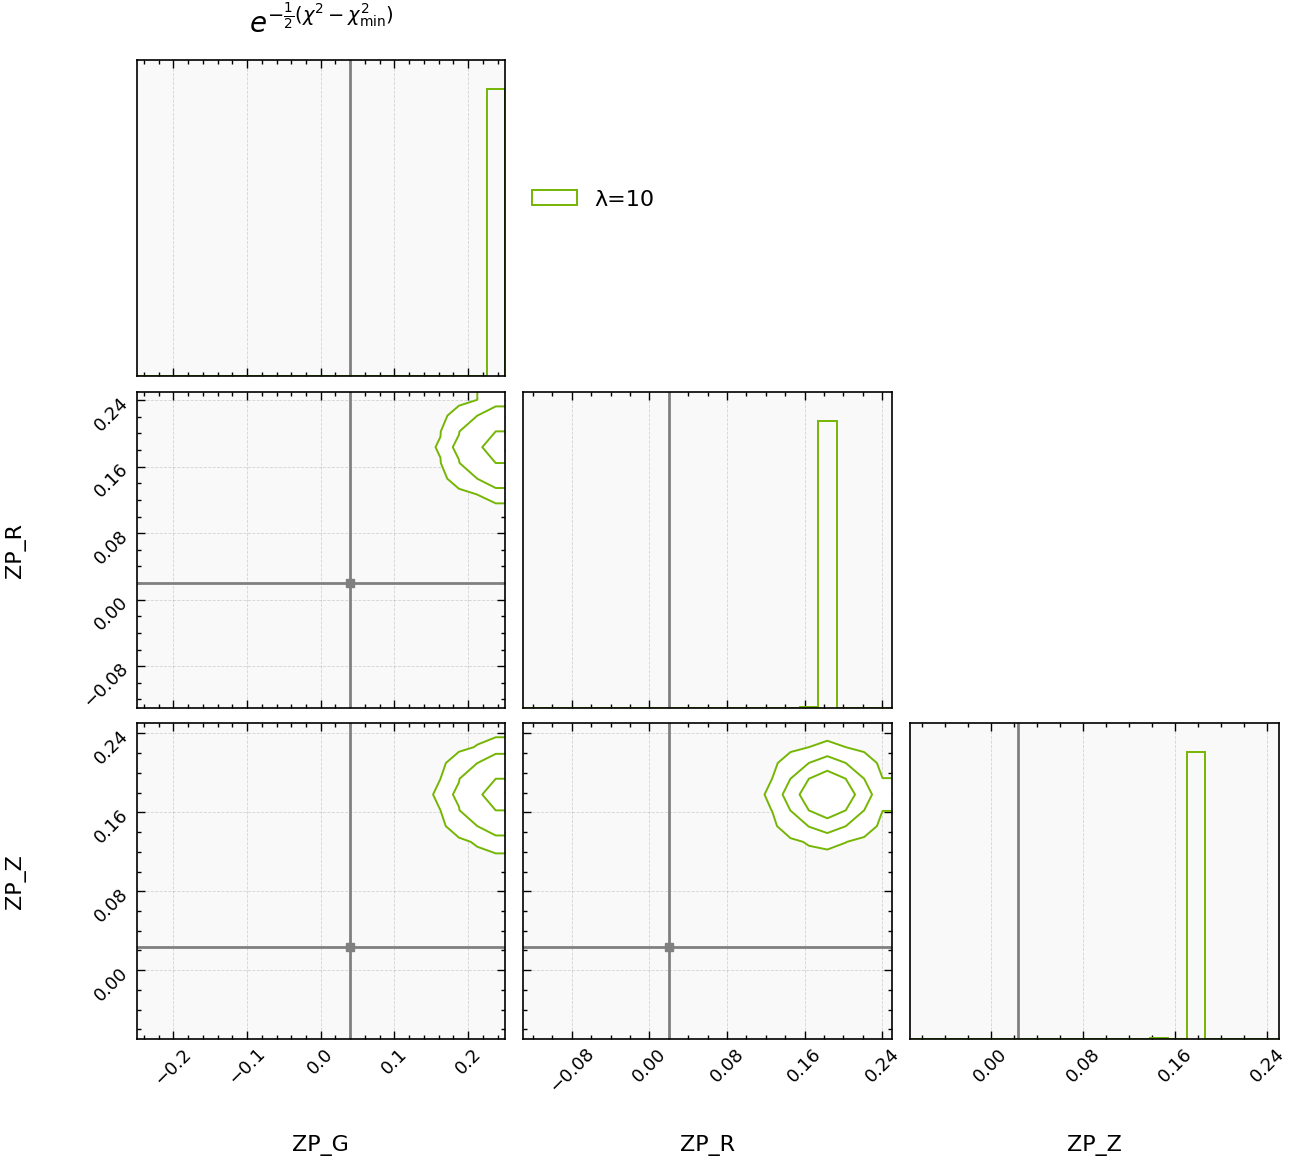

/tmp/ipykernel_2300318/3477090814.py:34: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_zp = np.cov(samples.T, aweights=weights)
/user/animesh.sah/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)
/user/animesh.sah/.local/lib/python3.10/site-packages/corner/core.py:800: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X2, Y2, H2.T, V, **contour_kwargs)


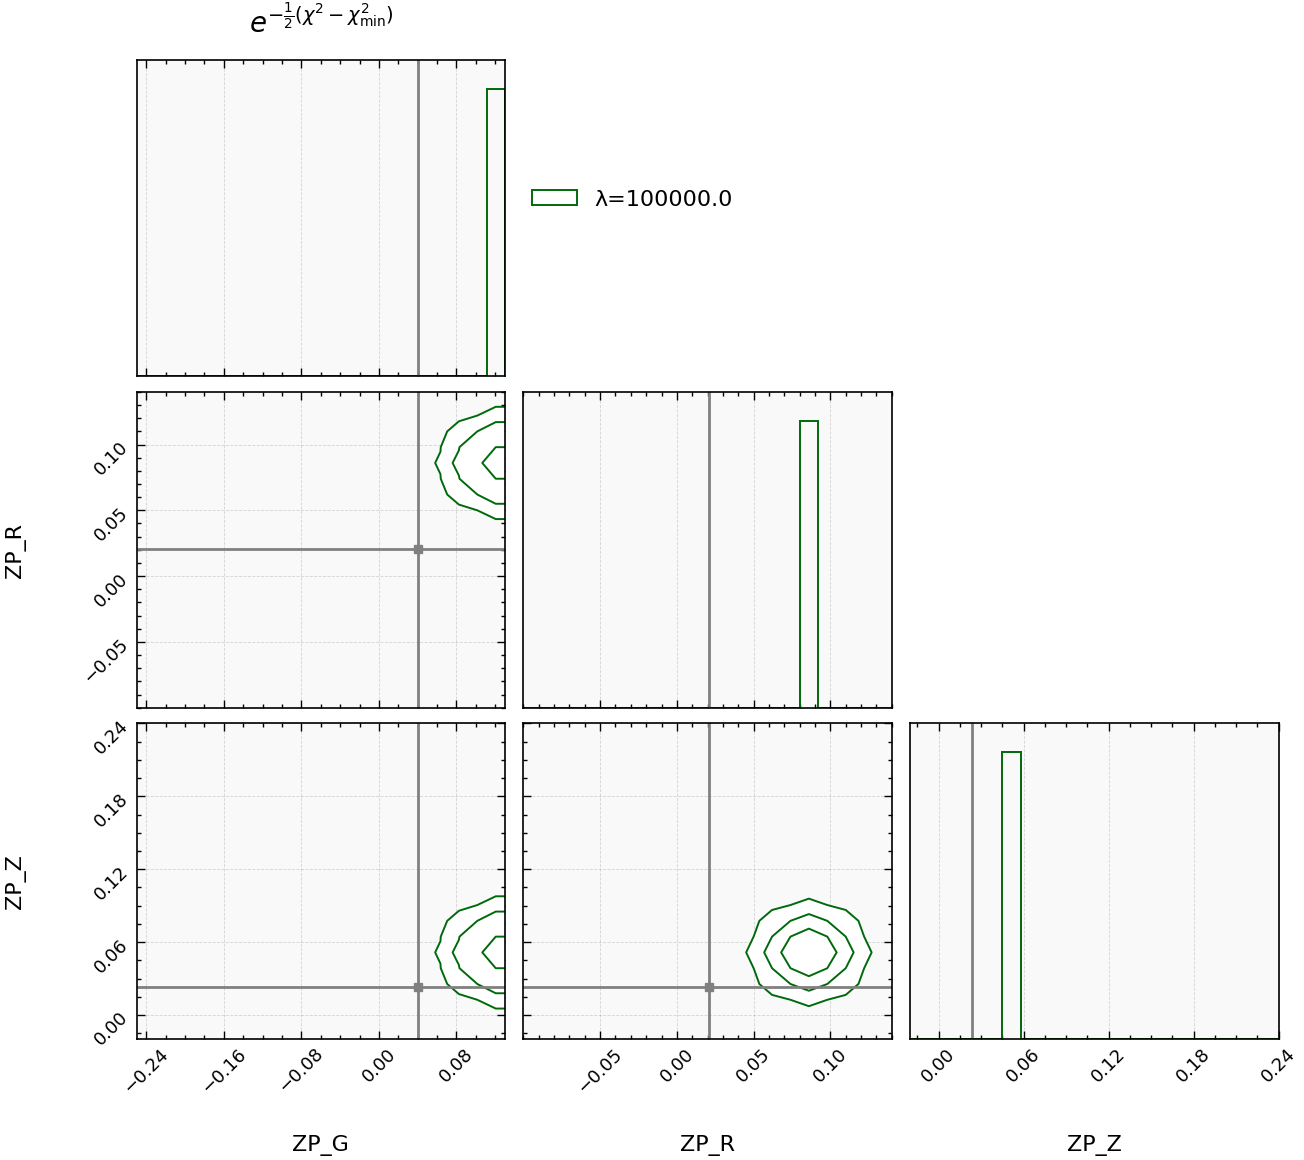

In [ ]:

colors = [
    "#484848",  # deep blue
    "#dc1616",  # violet
    "#07e812", 
    "#1c44e7",  # muted red
     # amber
    "#eb67a2",  # green-teal
        "#00ffe5",  # pink
        "#000000",  # light red-orange
        "#75b604",  
        "#00690B", 
]

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "font.size": 15,
    "axes.linewidth": 1.2,
})
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.15
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.linewidth"] = 0.6
  


for idx, lambda_val in enumerate(lambda_array):
    fig = plt.figure(figsize=(14, 12)) 
    values = chi_square_lambda[lambda_val]
    chi_grid = values['chi_square_grid']
    samples, weights = extract_samples_weights(chi_grid)
    mean_zp = np.average(samples, axis=0, weights=weights)
    cov_zp = np.cov(samples.T, aweights=weights)
    std_zp = np.sqrt(np.diag(cov_zp))
    
    alpha_contour = max(0.05, 0.8 - idx * 0.01)
    alpha_hist = max(0.2, 0.7 - idx * 0.1)

    fig = corner.corner(
        samples,
        weights=weights,
        labels=[r"ZP_G", r"ZP_R", r"ZP_Z"],
        color=colors[idx],
        levels=[0.68, 0.95, 0.997],
        fill_contours=False,
        smooth=1.0,     
        truths=[0.0403, 0.0206, 0.0234],
        truth_color="gray",
        plot_density=False,
        truth_linestyle=":",
        kde=True,
        plot_datapoints=False,
        show_titles=False,
        contour_kwargs={"linewidths": 1.4, "colors": colors[idx], "label": f"λ={lambda_val}"},
        hist_kwargs={"linewidth": 1.4, "color": colors[idx], "label": f"λ={lambda_val}"},
        fig=fig
    )

# Add legend to one of the diagonal subplots
    axes = fig.get_axes()
    for ax in fig.get_axes():
        ax.set_facecolor("#f9f9f9")  # very light grey background
    axes[0].legend(
        loc=(10,-0.5),
        bbox_to_anchor=(1.05, 0.5),
        fontsize=16,
        frameon=False)
        
    axes = fig.get_axes()
    axes[0].set_title(r"$e^{-\frac{1}{2}(\chi^2 - \chi^2_{\min})}$", fontsize=20, pad=20)
    plt.show()


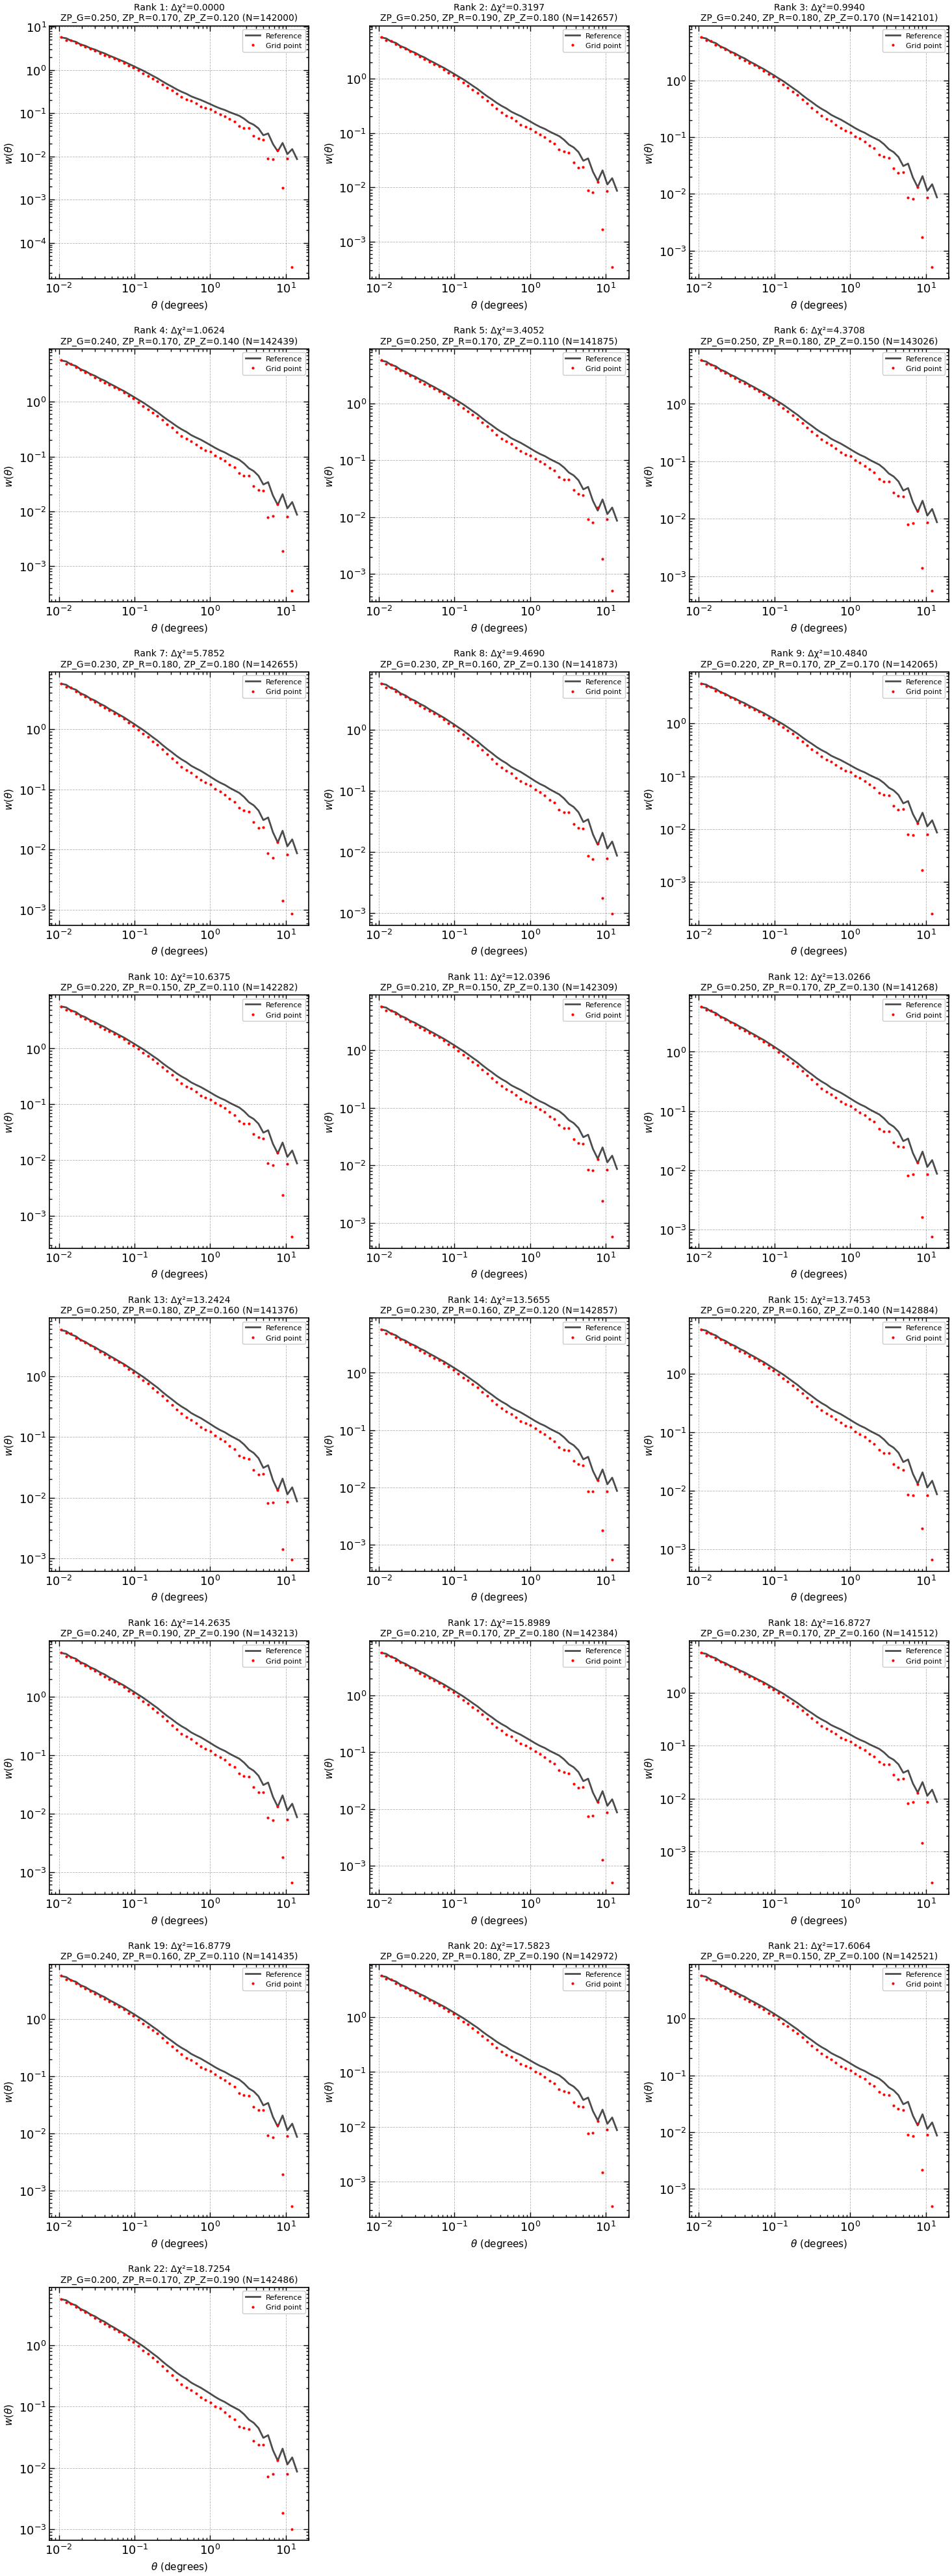

Number of grid points with Δχ² < 0.05: 22
Δχ² range: [0.000000, 18.725350]


In [ ]:
condition = np.where(chi < 20)
selected_indices = np.array([condition[0], condition[1], condition[2]]).T

# Get chi-square values for selected indices
selected_chi_values = chi[condition]

# Sort indices by chi-square values
sorted_order = np.argsort(selected_chi_values)
sorted_indices = selected_indices[sorted_order]
sorted_chi = selected_chi_values[sorted_order]

# Plot each w_theta in separate subplots
n_plots = len(sorted_indices)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx_num, (idx, ax) in enumerate(zip(sorted_indices, axes)):
    i, j, k = idx
    if valid_mask[i, j, k]:
        n_bins = n_bins_array[i, j, k]
        theta_bins = theta_bins_array[i, j, k, :n_bins]
        w_theta = w_theta_array[i, j, k, :n_bins]
        
        # Plot reference
        ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=2, 
                  label='Reference', alpha=0.7)
        # Plot grid point
        ax.loglog(theta_bins, w_theta, 'r.', markersize=4, 
                 label=f'Grid point')
        
        ax.set_xlabel(r'$\theta$ (degrees)', fontsize=11)
        ax.set_ylabel(r'$w(\theta)$', fontsize=11)
        ax.set_title(f'Rank {idx_num+1}: Δχ²={sorted_chi[idx_num]:.4f}\n' +
                    f'ZP_G={grid_values[i]:.3f}, ZP_R={grid_values[j]:.3f}, ZP_Z={grid_values[k]:.3f}' +
                    f' (N={n_objects[i, j, k]})',
                    fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Number of grid points with Δχ² < 0.05: {len(sorted_indices)}")
print(f"Δχ² range: [{sorted_chi.min():.6f}, {sorted_chi.max():.6f}]")


In [ ]:
condition = np.where(chi < 0.05)
selected_indices = np.array([condition[0], condition[1], condition[2]]).T

# Get chi-square values for selected indices
selected_chi_values = chi[condition]

# Sort indices by chi-square values
sorted_order = np.argsort(selected_chi_values)
sorted_indices = selected_indices[sorted_order]
sorted_chi = selected_chi_values[sorted_order]

#

# Plot reference w_theta
ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=3, 
          label='Reference (South)', alpha=0.8, zorder=100)

# Plot all w_theta with chi < 0.05 in increasing chi-square order
# Use colormap to show progression from best to worst fit
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, len(sorted_indices)))

for idx_num, idx in enumerate(sorted_indices):
    i, j, k = idx
    if valid_mask[i, j, k]:
        n_bins = n_bins_array[i, j, k]
        theta_bins = theta_bins_array[i, j, k, :n_bins]
        w_theta = w_theta_array[i, j, k, :n_bins]
        
        ax.loglog(theta_bins, w_theta, '.', alpha=0.3, color=colors[idx_num],
                 markersize=3)

# Add colorbar to show chi-square progression
sm = cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=sorted_chi.min(), vmax=sorted_chi.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Δχ²')

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=13)
ax.set_ylabel(r'$w(\theta)$', fontsize=13)
ax.set_title(f'w(θ) for Grid Points with Δχ² < 0.05 (N={len(sorted_indices)})\nColored by increasing Δχ²', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print(f"Number of grid points with Δχ² < 0.05: {len(sorted_indices)}")
print(f"Δχ² range: [{sorted_chi.min():.6f}, {sorted_chi.max():.6f}]")


<Figure size 800x600 with 0 Axes>

Number of grid points with Δχ² < 0.05: 1
Δχ² range: [0.000000, 0.000000]


# Using Zero points estimated from the median difference

In [ ]:
zp_G = 0.0403
zp_R = 0.0206
zp_Z = 0.0234

np.diff(grid_values)
for zero_points in [zp_G, zp_R, zp_Z]:
    idx = np.isclose(grid_values, zero_points, atol=0.004)
    if np.any(idx):
        print(f"Zero point {zero_points} is in the grid at index {np.where(idx)[0][0]} (grid value: {grid_values[idx][0]:.4f})")
    else:
        print(f"Zero point {zero_points} is NOT in the grid.")
    


Zero point 0.0403 is in the grid at index 21 (grid value: 0.0400)
Zero point 0.0206 is in the grid at index 23 (grid value: 0.0200)
Zero point 0.0234 is in the grid at index 23 (grid value: 0.0200)


In [89]:
Gg, Rg, Zg = np.meshgrid(grid_values, grid_values, grid_values, indexing='ij')
samples = np.column_stack([Gg.ravel(), Rg.ravel(), Zg.ravel()])

np.where((abs(samples[:, 0] - 0.04) <1e-5) & (abs(samples[:, 1]- 0.2) <1e-5) & (abs(samples[:, 2]- 0.2) <1e-5))

(array([54881]),)

In [90]:
chi_square_grid.ravel()[54881]

152.07367102655817